## NLP Quest 03

# <center>Transformer로 번역기 만들기</center>

---
## 프로젝트 개요
| 항목 | 내용 |
|------|------|
| **목표** | Transformer 모델로 한→영 번역기 구현 |
| **데이터** | 한영 병렬 말뭉치 (korean-english-park) |
| **토크나이저** | SentencePiece (BPE) |
| **프레임워크** | PyTorch |
| **평가** | 번역 품질 + Attention Map 시각화 |

---

## 진행 과정

1) 데이터 전처리(정제 및 토큰화(SentencePiece)
2) 모델 구성(모듈 조립)
3) 훈련시키기  
   (1) Optimizer & Loss  
   (2) Train_step 구현(Loss 계산 후 반환)  
   (3) 학습 진행
4) 번역 확인 및 시각화

---
## 최종본 수정사항 정리

| # | 항목 | 상태 | 비고 |
|---|---|---|---|
| 1 | 임베딩 초기화 (`std=d_model**-0.5`) | ✅ 완료 | Epoch1 loss 126→7.2, 번역 품질 개선의 핵심 원인으로 실증됨 |
| 2 | DecoderLayer dropout 전달 | ✅ 완료 | `MultiHeadAttention(d_model, num_heads, dropout)` |
| 3 | 전처리 정규식 숫자 포함 | ✅ 완료 | 코퍼스 재정제로 데이터 수 78,848→78,948, 선별 데이터 75,378→74,265로 변동 (재학습 반영 확인) |
| 4 | 죽은 코드(`TranslationDataset`/`build_dataloader`) 제거 | ✅ 완료 | — |
| 5 | 학습 에폭 연장 | ✅ 완료 | `EPOCHS=20`, 10→20 epoch 완주 확인 |
| — | Best Model Load 체크포인트 dict 처리 | 🟡 회피 | 에러 나던 로드 셀 자체를 삭제 (수정이 아니라 제거) → 현재 사후 평가는 epoch20 기준 |



# 0. 프로젝트 환경설정

PyTorch와 matplotlib을 사용한다. 결과 재현을 위해 시드를 고정하고, 그래프의 한국어 라벨이 깨지지 않도록 시스템 한국어 폰트를 자동 선택한다.

In [5]:
# 한국어 포함 말뭉치를 이용, 시각화 하기 위해서 matplotlib에 한국어 지원 폰트 변경 (Colab)

!apt-get -qq -y install fonts-nanum
!rm -rf /root/.cache/matplotlib

Selecting previously unselected package fonts-nanum.
(Reading database ... 122403 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [1]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

## 라이브러리 로드

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import sentencepiece as spm

import re
import os
import io
import time
import random
import math

import seaborn # Attention 시각화를 위해 필요!

print(torch.__version__)
print(np.__version__)
print(spm.__version__)

2.11.0+cu128
2.0.2
0.2.1


✅ 사용 디바이스: cuda


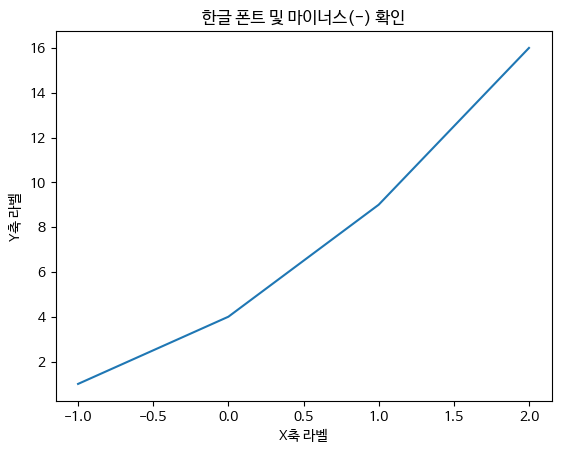

3.10.0


In [3]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 재현성 확보
torch.manual_seed(42)
np.random.seed(42)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print('✅ 사용 디바이스:', DEVICE)

# 1. 나눔바른고딕 폰트 지정
plt.rc('font', family='NanumBarunGothic')

# 2. 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# 3. 한글 출력 확인용 테스트 그래프
plt.plot([-1, 0, 1, 2], [1, 4, 9, 16])
plt.title('한글 폰트 및 마이너스(-) 확인')
plt.xlabel('X축 라벨')
plt.ylabel('Y축 라벨')
plt.show()

print(mpl.__version__)

# 1. 데이터 다운로드

In [ ]:
# !mkdir ~/work/transformer/data

In [ ]:
# !wget https://github.com/jungyeul/korean-parallel-corpora/raw/master/korean-english-news-v1/korean-english-park.train.tar.gz -P ~/work/transformer/data
# !gzip -d ~/work/transformer/data/korean-english-park.train.tar.gz
# !tar -xvf ~/work/transformer/data/korean-english-park.train.tar

In [ ]:
# # 1. data 폴더 생성 (이미 존재하면 만들지 않음)
# !mkdir -p /content/data

# # 2. 지정한 디렉토리(/content/data)에 다운로드
# !wget https://github.com/jungyeul/korean-parallel-corpora/raw/master/korean-english-news-v1/korean-english-park.train.tar.gz -P /content/data
# # 3. gzip 압축 해제
# !gzip -d /content/data/korean-english-park.train.tar.gz
# # 4. tar 아카이브 해제 (-C 옵션을 사용하여 /content/data 폴더 내에 풀도록 지정)
# !tar -xvf /content/data/korean-english-park.train.tar -C /content/data

In [4]:
# Colab용 환경 설정
CURRENT_DIR = os.getcwd()
DATA_PATH = os.path.join(CURRENT_DIR, 'data')

os.makedirs(DATA_PATH, exist_ok=True)
print(CURRENT_DIR)
print(DATA_PATH)

/content
/content/data


In [5]:
import os

# 데이터 파일 경로 설정
# data_dir = os.path.join(os.getenv("HOME"), 'work/transformer/data')  # 홈 디렉토리 기반 데이터 폴더 경로
# kor_path = data_dir + "/korean-english-park.train.ko"  # 한국어 파일 경로
# eng_path = data_dir + "/korean-english-park.train.en"  # 영어 파일 경로

# colab용 path
KOR_PATH = f"{DATA_PATH}/korean-english-park.train.ko"
ENG_PATH = f"{DATA_PATH}/korean-english-park.train.en"


# 데이터 미리보기
with open(KOR_PATH) as f:
    ko_lines = f.readlines()
with open(ENG_PATH) as f:
    en_lines = f.readlines()

print(f'\n총 데이터 수: {len(ko_lines):,}개')
print('\n[한국어 예시]')
for line in ko_lines[:3]:
    print(' ', line.strip())
print('\n[영어 예시]')
for line in en_lines[:3]:
    print(' ', line.strip())


총 데이터 수: 94,123개

[한국어 예시]
  개인용 컴퓨터 사용의 상당 부분은 "이것보다 뛰어날 수 있느냐?"
  모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하지 않는다.
  그러나 이것은 또한 책상도 필요로 하지 않는다.

[영어 예시]
  Much of personal computing is about "can you top this?"
  so a mention a few weeks ago about a rechargeable wireless optical mouse brought in another rechargeable, wireless mouse.
  Like all optical mice, But it also doesn't need a desk.


# 2. 데이터 정제 및 토큰화

1) **중복 제거 & 정제**
- `set` 데이터형이 중복을 허용하지 않는다는 것을 활용하여 중복 데이터를 제거한다. <br>
- 데이터의 병렬 쌍이 흐트러지지 않도록 주의하여 중복을 제거한 데이터인 `cleaned_corpus`를 저장한다.

2) **데이터 정제**
+ 모든 입력을 소문자로 변환
+ 알파벳, 문장부호, 한글만 남기고 모두 제거
+ 문장부호 양옆에 공백을 추가
+ 문장 앞뒤의 불필요한 공백 제거

3) **데이터 토큰화 (`Sentencepiece` - `generate_tokenizer()`)**
+ 한글 말뭉치 `kor_corpus` 와 영문 말뭉치 `eng_corpus` 를 각각 분리
+ 단어 사전을 매개변수로 받아 원하는 크기의 사전을 정의할 수 있게 한다(기본: 20,000)
+ 학습후 저장된 `model` 파일을 `SentencePieceProcessor()` 클래스에 `Load()` 한 후 반환
+ 특수 토큰의 인덱스를 다음과 동일하게 지정. `<PAD>` : 0 / `<BOS>` : 1 / `<EOS>` : 2 / `<UNK>` : 3
+ 영어 타겟 앞 뒤로 bos eos 추가. => 토크나이저를 순수하게 토크나이저로 유지하기 위해서 타켓 앞 뒤로 특수토큰을 넣는것은 데이터셋에서 진행

4) **텐서 변환**
+ 토크나이저를 활용해 토큰의 길이가 `50` 이하인 데이터를 선별하여 `src_corpus` 와 `tgt_corpus` 를 각각 구축하고, 텐서 `enc_train` 과 `dec_train` 으로 변환한다.

### 텍스트 전처리 `preprocess_sentence` 함수

In [6]:
def preprocess_sentence(sentence):

  sentence = sentence.lower()
  sentence = re.sub(r"[^a-zA-Z가-힣0-9?.!,]+", " ", sentence)
  sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
  sentence = re.sub(r'[" "]+', " ", sentence)

  return sentence

print("데이터 전처리 함수 정의")

데이터 전처리 함수 정의


### 텍스트 정제 `clean_corpus` 함수

In [7]:
# 한영 병렬 코퍼스 로드 및 정제 (완전히 동일한 쌍만 제거)

seen = set()
cleaned_corpus = []

def clean_corpus(kor_path, eng_path):
    """
    한영 병렬 코퍼스 로드 및 정제

    인자:
        kor_path: 한국어 텍스트 파일 경로
        eng_path: 영어 텍스트 파일 경로

    반환:
        정제된 코퍼스 리스트 (중복 제거)
    """
    # 한국어 파일 로드 (각 줄을 리스트로 변환)
    with open(KOR_PATH, "r") as f:
        kor = f.read().splitlines()

    # 영어 파일 로드 (각 줄을 리스트로 변환)
    with open(ENG_PATH, "r") as f:
        eng = f.read().splitlines()

    # 한국어와 영어 문장 개수가 같은지 확인
    assert len(kor) == len(eng)

    # 데이터 전처리
    for ko, en in zip(kor, eng):
      ko_prep, en_prep = preprocess_sentence(ko), preprocess_sentence(en)
      key = (ko_prep, en_prep)

      if key not in seen and ko_prep and en_prep:
        seen.add(key)
        cleaned_corpus.append((ko_prep, en_prep))

    return cleaned_corpus

# 정제된 코퍼스 생성
cleaned_corpus = clean_corpus(KOR_PATH, ENG_PATH)

print(f'원본: {len(ko_lines):,}개  →  중복 제거 후: {len(cleaned_corpus):,}개')
print('\n예시:')
for ko, en in cleaned_corpus[:3]:
    print(f'  KO: {ko}')
    print(f'  EN: {en}')
    print()

원본: 94,123개  →  중복 제거 후: 78,948개

예시:
  KO: 개인용 컴퓨터 사용의 상당 부분은 이것보다 뛰어날 수 있느냐 ? 
  EN: much of personal computing is about can you top this ? 

  KO: 모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하지 않는다 . 
  EN: so a mention a few weeks ago about a rechargeable wireless optical mouse brought in another rechargeable , wireless mouse . 

  KO: 그러나 이것은 또한 책상도 필요로 하지 않는다 . 
  EN: like all optical mice , but it also doesn t need a desk . 



### 토크나이저 구성

---
| 함수 | 내용 |
|------|------|
| **save_corpus()** | txt 파일 저장 |
| **train_tokenizer()** | SentencePiece 학습 |
| **load_tokenizer()** | `.model` 로드 |
| **build_tokenizer** | 학습 여부 판단 후 train/load 수행 |



In [8]:
# 중복을 제거한 문장들을 txt 파일로 저장

def save_corpus(corpus, file_path):
    """
    문장 리스트를 SentencePiece 학습용 txt 파일로 저장

    Args:
        corpus (list[str]): 문장 리스트
        file_path (str): 저장할 txt 파일 경로
    """

    os.makedirs(os.path.dirname(file_path), exist_ok=True)

    with open(file_path, "w", encoding="utf-8") as f:
        for sentence in corpus:
            f.write(sentence.strip() + "\n")

In [9]:
# SentencePiece 학습

def train_tokenizer(
    input_file,
    model_prefix,
    vocab_size=20000,
    model_type="bpe",
    character_coverage=1.0,
    pad_id=0,
    bos_id=1,
    eos_id=2,
    unk_id=3
):
    """
    SentencePiece 모델 학습

    Args:
        input_file (str)
        model_prefix (str)
    """

    spm.SentencePieceTrainer.train(
        input=input_file,
        model_prefix=model_prefix,
        vocab_size=vocab_size,
        model_type=model_type,
        character_coverage=character_coverage,
        pad_id=pad_id,
        bos_id=bos_id,
        eos_id=eos_id,
        unk_id=unk_id
    )

print("토크나이저 학습 함수")

토크나이저 학습 함수


In [10]:
# .model 로드

def load_tokenizer(model_prefix):
    """
    학습된 SentencePiece 모델 로드

    Args:
        model_prefix (str)

    Returns:
        SentencePieceProcessor
    """

    sp = spm.SentencePieceProcessor()
    sp.Load(f"{model_prefix}.model")

    return sp

print("토크나이저 로드 함수")

토크나이저 로드 함수


In [11]:
# 학습 여부 판단 후 train/load 수행

def build_tokenizer(
    corpus_path,
    save_dir,
    prefix,
    vocab_size=20000,
    force_train=False
):
    """
    SentencePiece 토크나이저 생성

    이미 모델이 존재하면 로드만 수행.
    없으면 corpus를 저장하고 새로 학습.

    Args:
        corpus (list[str])
        save_dir (str)
        prefix (str)

    Returns:
        SentencePieceProcessor
    """

    os.makedirs(save_dir, exist_ok=True)

    model_prefix = os.path.join(save_dir, f"{prefix}_spm")
    model_file = model_prefix + ".model"

    # 모델이 없거나 강제 재학습이라면 학습 진행
    if force_train or not os.path.exists(model_file):

      print(f"🔧 {prefix} tokenizer training...")

      train_tokenizer(
          input_file = corpus_path,
          model_prefix = model_prefix,
          vocab_size = vocab_size
      )

    else :
      print(f"📦 {prefix} tokenizer already exists.")


    return load_tokenizer(model_prefix)

print("토크나이저 빌드 함수")

토크나이저 빌드 함수


In [12]:
# 병렬 코퍼스 분리
kor_corpus = [ko for ko, _ in cleaned_corpus]
eng_corpus = [en for _, en in cleaned_corpus]

# 한영 corpus txt 저장
KO_CORPUS = f'{DATA_PATH}/ko_corpus.txt'
EN_CORPUS = f'{DATA_PATH}/en_corpus.txt'

save_corpus(kor_corpus, KO_CORPUS)
save_corpus(eng_corpus, EN_CORPUS)

In [13]:
# 토크나이저 생성

VOCAB_SIZE = 20000


ko_tokenizer = build_tokenizer(
    corpus_path=KO_CORPUS,
    save_dir = DATA_PATH,
    prefix = "ko",
    vocab_size = VOCAB_SIZE
)

en_tokenizer = build_tokenizer(
    corpus_path=EN_CORPUS,
    save_dir = DATA_PATH,
    prefix = "en",
    vocab_size = VOCAB_SIZE
)

print("한-영 토크나이저 생성")

# 토크나이저 확인
test_ko = '오바마는 대통령이다 .'
test_en = 'obama is the president .'
print(f'\nKO 토크나이즈: {ko_tokenizer.encode(test_ko)}')
print(f'EN 토크나이즈: {en_tokenizer.encode(test_en)}')

📦 ko tokenizer already exists.
📦 en tokenizer already exists.
한-영 토크나이저 생성

KO 토크나이즈: [1229, 79, 132, 4]
EN 토크나이즈: [532, 81, 9, 230, 15]


### 텐서 변환 (토큰 길이 50 이하 선별)

In [14]:
# 토크나이저를 활용해 토큰 길이가 50 이하인 데이터만 선별 src_corpus, tgt_corpus 구축한 후
# 텐서 enc_train, dec_train 으로 변환


from torch.nn.utils.rnn import pad_sequence

MAX_LEN = 50

def build_dataset(
    cleaned_corpus,
    ko_tokenizer,
    en_tokenizer,
    max_len = MAX_LEN
):
  """
  SentencePiece 토크나이저를 이용하여 학습용 데이터셋 생성

  Args:
    cleaned_corpus (list[tuple]): [(한국어 문장, 영어 문장), ...]

    ko_tokenizer (SentencePieceProcessor)
    en_tokenizer (SentencePieceProcessor)
    max_len (int): 최대 허용 토큰 길이 (BOS/EOS 포함)

  Returns:
    src_corpus (list[list[int]])
    tgt_corpus (list[list[int]])
    enc_train (LongTensor)
    dec_train (LongTensor)

  """

  src_corpus = []
  tgt_corpus = []

  BOS = en_tokenizer.bos_id()
  EOS = en_tokenizer.eos_id()
  PAD = en_tokenizer.pad_id()

  for ko, en in cleaned_corpus:
    #SentencePiece Encoding
    src_ids = ko_tokenizer.encode(ko)
    tgt_ids = en_tokenizer.encode(en)

    # Target에 BOS/EOS 추가
    tgt_ids = [BOS] + tgt_ids + [EOS]

    # 길이 제한 (50 이하)
    if len(src_ids) <= max_len and len(tgt_ids) <= max_len:
      src_corpus.append(torch.tensor(src_ids, dtype=torch.long))
      tgt_corpus.append(torch.tensor(tgt_ids, dtype=torch.long))

  # Padding

  SRC_PAD = ko_tokenizer.pad_id()
  TGT_PAD = en_tokenizer.pad_id()

  enc_train = pad_sequence(
      src_corpus,
      batch_first=True,
      padding_value = SRC_PAD
  )

  dec_train = pad_sequence(
      tgt_corpus,
      batch_first=True,
      padding_value = TGT_PAD
  )

  return src_corpus, tgt_corpus, enc_train, dec_train


src_corpus, tgt_corpus, enc_train, dec_train = build_dataset(
    cleaned_corpus,
    ko_tokenizer,
    en_tokenizer,
    max_len = MAX_LEN
)


print(f"✅ 토큰 길이 50 이하 데이터 선별 완료")
print(f"   선별된 데이터 개수: {len(src_corpus)}")
print(f"   전체 데이터 개수: {len(cleaned_corpus)}")
print(f"   필터링된 데이터: {len(cleaned_corpus) - len(src_corpus)}개")

print(f"\n✅ 텐서 변환 완료")
print(f"   enc_train shape: {enc_train.shape}")
print(f"   dec_train shape: {dec_train.shape}")
print(f"   enc_train dtype: {enc_train.dtype}")
print(f"   dec_train dtype: {dec_train.dtype}")

# 샘플 데이터 확인
print(f"\n📊 샘플 데이터 확인")
print(f"   첫 번째 소스 토큰 길이: {len(src_corpus[0])}")
print(f"   첫 번째 타겟 토큰 길이: {len(tgt_corpus[0])}")
print(f"   enc_train[0]: {enc_train[0]}")
print(f"   dec_train[0]: {dec_train[0]}")

✅ 토큰 길이 50 이하 데이터 선별 완료
   선별된 데이터 개수: 74265
   전체 데이터 개수: 78948
   필터링된 데이터: 4683개

✅ 텐서 변환 완료
   enc_train shape: torch.Size([74265, 50])
   dec_train shape: torch.Size([74265, 50])
   enc_train dtype: torch.int64
   dec_train dtype: torch.int64

📊 샘플 데이터 확인
   첫 번째 소스 토큰 길이: 14
   첫 번째 타겟 토큰 길이: 13
   enc_train[0]: tensor([ 1489, 18461,  1092,   376, 18337,  3216,  9990,  1426,   501,  4478,
        18606,    17, 17412,  1000,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0])
   dec_train[0]: tensor([    1,  1092,    37,  3005, 13510,    81,   251,   344,   461,   822,
          233,  1171,     2,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,   

# 3. 모델 설계

## 내부 모듈 구현

### Positional Encoding

---
+ 입력 임베딩에 위치 정보를 더해주는 모듈
+ sinusoid(`sin/con` 함수) 사용. 각 위치마다 고유한 패턴 생성
+ 수식 :   
  $$PE(pos, 2i) = sin(\frac{pos}{10000^{2i/d\_model}})$$  
  $$PE(pos, 2i+1) = cos(\frac{pos}{10000^{2i/d\_model}})$$  

PE는 학습대상이 아니기 때문에 `register_buffer()`를 사용.  
+ optimizer가 업데이트하지 않고
+ GPU 로 자동 이동하며
+ state_dict에 저장 된다

In [15]:
# PE : Shape 변화 없음 [batch size x length]

class PositionalEncoding(nn.Module):
    """
    Sinusoidal Positional Encoding

    Input:
        (batch_size, seq_len, d_model)

    Output:
        (batch_size, seq_len, d_model)
    """

    def __init__(
        self,
        d_model,
        max_len = 5000,
        dropout = 0.1
    ):
      super().__init__()

      self.dropout = nn.Dropout(dropout)

      # (max_len, d_model)
      pe = torch.zeros(max_len, d_model)

      # (max_len, 1)
      position = torch.arange(
          max_len
      ).unsqueeze(1).float()

      # (d_model/2)
      div_term = torch.exp(
          torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
      )

      pe[:, 0::2] = torch.sin(position * div_term) # 짝수 : sin
      pe[:, 1::2] = torch.cos(position * div_term) # 홀수 : cos

      # (1, max_len, d_model)
      pe = pe.unsqueeze(0)

      self.register_buffer('pe', pe)

    def forward(self, x):
        """
        Args:
            x:
                (batch_size, seq_len, d_model)
        """
        seq_len = x.size(1)
        x = x + self.pe[:, :seq_len]

        return self.dropout(x)

print("Positional Embedding 함수 구현")

# 동작 확인
pe_test = PositionalEncoding(d_model=512)
x_test  = torch.zeros(2, 10, 512)  # [batch=2, length=10, d_model=512]
out_test = pe_test(x_test)
print('✅ Positional Encoding 출력 shape:', out_test.shape)  # [2, 10, 512]

Positional Embedding 함수 구현
✅ Positional Encoding 출력 shape: torch.Size([2, 10, 512])


### Multi-Head Attention

---

- `split_heads()`: d_model → [batch, heads, length, depth]
- `scaled_dot_product_attention()`: Attention(Q, K, V) = softmax(QK^T / √d_k) · V
- `combine_heads()`: 분할된 Head 결합
- Masking 지원 (Padding / Causality)


In [16]:
class ScaledDotProductAttention(nn.Module):
    """
    Scaled Dot-Product Attention

    Input
        Q : (B, H, Lq, D)
        K : (B, H, Lk, D)
        V : (B, H, Lv, D)

    Output
        output      : (B, H, Lq, D)
        attention   : (B, H, Lq, Lk)
    """

    def __init__(self, dropout=0.1):
      super().__init__()
      self.dropout = nn.Dropout(dropout)

    def forward(self, Q, K, V, mask=None):
      d_k = K.size(-1)

      scores = torch.matmul(Q, K.transpose(-2, -1))
      scores = scores / math.sqrt(d_k)

      if mask is not None:
        scores = scores.masked_fill(mask, float("-inf"))

      attention = F.softmax(scores, dim=-1)
      attention = torch.nan_to_num(attention)
      attention = self.dropout(attention)

      output = torch.matmul(attention, V)

      return output, attention

print("Scaled Dot Product Attention 클래스 정의")

Scaled Dot Product Attention 클래스 정의


In [17]:
# MHA : Split Heads -> Masking for Masked Attention -> Scaled Dot Product Attention -> Combine Heads
# 모델 외부의 훈련 데이터가 마스크의 형태를 결정하기 때문에 마스크를 구현하는 함수는 따로 구현한다.

class MultiHeadAttention(nn.Module):
    """
    Multi-Head Attention

    Input
        Q : (B, Lq, d_model)
        K : (B, Lk, d_model)
        V : (B, Lv, d_model)

    Output
        output
            (B, Lq, d_model)

        attention
            (B, H, Lq, Lk)
    """

    def __init__(self, d_model, num_heads, dropout=0.1):
      super().__init__()

      assert d_model % num_heads == 0, \
            "d_model must be divisible by num_heads."

      self.d_model = d_model # 토큰 임베딩 차원
      self.num_heads = num_heads # 어텐션 헤드 수
      self.depth = d_model // num_heads # 헤드 한 개의 차원


      # Q, K, V 선형 변환 계층
      self.W_q = nn.Linear(d_model, d_model)
      self.W_k = nn.Linear(d_model, d_model)
      self.W_v = nn.Linear(d_model, d_model)

      # Attention
      self.attention = ScaledDotProductAttention(dropout)

      # Output Projection
      self.fc = nn.Linear(d_model, d_model)



    def split_heads(self, x):
        """
        (B, L, d_model)
            ↓
        (B, H, L, depth)
        """
        B, L, _ = x.size()
        x = x.view(
            B,
            L,
            self.num_heads,
            self.depth
        )  # [batch_size, length, num_heads, depth]
        x = x.permute(0, 2, 1, 3)  # [batch_size, num_heads, length, depth]로 변환

        return x

    def combine_heads(self, x):
        """
        (B, H, L, depth)
            ↓
        (B, L, d_model)
        """
        B = x.size(0)  # input shape = [batch_size, num_heads, length, depth]
        x = x.permute(0, 2, 1, 3).contiguous()  # [batch_size, length, num_heads, depth]로 변환
        x = x.view(B, -1, self.d_model)  # [batch_size, length, d_model]로 결합

        return x

    def forward(self, Q, K, V, mask=None):
        # Linear Projection: Q, K, V에 선형 변환 적용
        q = self.W_q(Q)
        k = self.W_k(K)
        v = self.W_v(V)

        #  Split Heads: 각 헤드별로 Q, K, V 분할
        q_splits = self.split_heads(q)
        k_splits = self.split_heads(k)
        v_splits = self.split_heads(v)

        # 멀티헤드 어텐션 계산
        out, attention = self.attention(
            q_splits, k_splits, v_splits, mask
        )

        # 여러 헤드의 출력 결합
        out = self.combine_heads(out)

        # 최종 선형 변환
        out = self.fc(out)

        return out, attention

print("Multi-Head Attention 클래스 정의")

# 동작 확인
mha_test = MultiHeadAttention(d_model=512, num_heads=8)
q = k = v = torch.zeros(2, 10, 512)  # [batch=2, length=10, d_model=512]
out, attn = mha_test(q, k, v)
print('✅ MHA 출력 shape:', out.shape)       # [2, 10, 512]
print('✅ Attention 가중치 shape:', attn.shape)  # [2, 8, 10, 10]

Multi-Head Attention 클래스 정의
✅ MHA 출력 shape: torch.Size([2, 10, 512])
✅ Attention 가중치 shape: torch.Size([2, 8, 10, 10])


### Position-wise Feed Forward Network

---
- Linear(d_model → d_ff) → ReLU → Linear(d_ff → d_model)

In [18]:
class FeedForward(nn.Module):
    """
    Position-wise Feed-Forward Network (FFN)
    Transformer의 인코더/디코더 블록에서 Multi-Head Attention 다음에 적용됨
    구조: Linear(d_model→d_ff) → ReLU → Linear(d_ff→d_model)

    Input:
        x : (batch_size, seq_len, d_model)

    Output:
        x : (batch_size, seq_len, d_model)
    """
    def __init__(self, d_model, d_ff):
        super().__init__()

        self.fc1 = nn.Linear(d_model, d_ff)  # 첫 번째 선형 레이어: d_model → d_ff로 확장
        self.fc2 = nn.Linear(d_ff, d_model)  # 두 번째 선형 레이어: d_ff → d_model로 축소
        self.relu = nn.ReLU()  # ReLU 활성화 함수

    def forward(self, x):
        # 입력: [batch_size, length, d_model]
        x = self.relu(self.fc1(x))  # [batch_size, length, d_ff]
        x = self.fc2(x)            # [batch_size, length, d_model]
        # 출력: [batch_size, length, d_model]

        return x

print("FFN 클래스 정의")

FFN 클래스 정의


## 모듈 조립

### Encoder Layer

---

- Self-Attention → Add & Norm → FFN → Add & Norm
- **Pre-LN** 구조: Norm이 sub-layer 입력 앞에 위치 (논문 Official 구현)

In [19]:
# Encoder Layer 디자인
# input embedding -> LayerNorm -> MHA(self) -> Dropout -> Residual Add -> LayerNorm -> FFN -> Dropout -> Residual Add

class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()

        self.enc_self_attn = MultiHeadAttention(d_model, num_heads, dropout)  # 멀티헤드 셀프 어텐션
        self.ffn = FeedForward(d_model, d_ff)  # Position-wise Feed Forward Network

        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)  # 첫 번째 LayerNorm (MHA 전)
        self.norm2 = nn.LayerNorm(d_model, eps=1e-6)  # 두 번째 LayerNorm (FFN 전)

        self.dropout = nn.Dropout(dropout)  # Dropout 층

    def forward(self, x, src_mask=None):
        """
        Multi-Head Self Attention with Residual Connection and Layer Normalization
        """
        residual = x  # 잔차 연결(Residual Connection)을 위해 입력 저장
        out = self.norm1(x)  # 입력에 LayerNorm 적용
        out, enc_attn = self.enc_self_attn(out, out, out, src_mask)  # 셀프 어텐션 (Q=K=V)
        out = self.dropout(out)  # Dropout 적용
        out = out + residual  # 잔차 연결: 원래 입력과 더함

        """
        Position-Wise Feed Forward Network with Residual Connection and Layer Normalization
        """
        residual = out  # 잔차 연결을 위해 어텐션 출력 저장
        out = self.norm2(out)  # LayerNorm 적용
        out = self.ffn(out)  # FFN 적용
        out = self.dropout(out)  # Dropout 적용
        out = out + residual  # 잔차 연결: 어텐션 출력과 더함

        return out, enc_attn

print("Encoder Layer 클래스 정의")

Encoder Layer 클래스 정의


### Decoder Layer

---
- Masked Self-Attention → Add & Norm
- Cross-Attention (Q=디코더, K/V=인코더) → Add & Norm
- FFN → Add & Norm

In [20]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(DecoderLayer, self).__init__()
        self.dec_self_attn = MultiHeadAttention(d_model, num_heads, dropout)  # 디코더 셀프 어텐션
        self.dec_enc_attn = MultiHeadAttention(d_model, num_heads, dropout)  # 인코더-디코더 크로스 어텐션
        self.ffn = FeedForward(d_model, d_ff)  # Position-wise Feed Forward Network

        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)  # 첫 번째 LayerNorm (디코더 셀프 어텐션 전)
        self.norm2 = nn.LayerNorm(d_model, eps=1e-6)  # 두 번째 LayerNorm (크로스 어텐션 전)
        self.norm3 = nn.LayerNorm(d_model, eps=1e-6)  # 세 번째 LayerNorm (FFN 전)

        self.dropout = nn.Dropout(dropout)  # Dropout 층

    def forward(self, x, enc_out, tgt_mask=None, src_mask=None):
        """
        Masked Multi-Head Self Attention with Causality Mask
        디코더가 미래 토큰을 참고하지 못하도록 causality mask 적용

        src_mask → Encoder 출력을 참조하는 Cross Attention용
        tgt_mask → Decoder Self-Attention용
        """
        residual = x  # 잔차 연결을 위해 입력 저장
        out = self.norm1(x)  # LayerNorm 적용
        out, dec_attn = self.dec_self_attn(out, out, out, tgt_mask)  # 셀프 어텐션 (Q=K=V) + causality mask
        out = self.dropout(out)  # Dropout 적용
        out = out + residual  # 잔차 연결

        """
        Encoder-Decoder Cross Attention
        디코더가 인코더의 출력을 참고하도록 하는 크로스 어텐션
        Q: 디코더 출력, K=V: 인코더 출력
        """
        residual = out  # 잔차 연결을 위해 저장
        out = self.norm2(out)  # LayerNorm 적용
        out, dec_enc_attn = self.dec_enc_attn(out, enc_out, enc_out, src_mask)  # 크로스 어텐션 (Q: dec, K=V: enc) + padding mask
        out = self.dropout(out)  # Dropout 적용
        out = out + residual  # 잔차 연결

        """
        Position-Wise Feed Forward Network with Residual Connection
        """
        residual = out  # 잔차 연결을 위해 저장
        out = self.norm3(out)  # LayerNorm 적용
        out = self.ffn(out)  # FFN 적용
        out = self.dropout(out)  # Dropout 적용
        out = out + residual  # 잔차 연결

        return out, dec_attn, dec_enc_attn

print("Decoder Layer 클래스 정의")

Decoder Layer 클래스 정의


### Encoder / Decoder / Transformer

---

지금까지 정의한 모듈들을 조립하여 Encoder, Decoder 클래스를 정의한다.
- N개의 레이어를 동적으로 쌓아 실험 가능
- `shared=True` 시 Decoder Embedding과 출력층 Weight 공유



In [21]:
# Pre-LN 구조: [Input] → [Norm] → [MHA] → [Residual] → [Norm] → [FFN] → [Residual]
# 논문 Official 구현 방식 (레이어 많을수록 Pre-LN이 유리)

class Encoder(nn.Module):
    def __init__(self, n_layers, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()

        self.enc_layers = nn.ModuleList([
            EncoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])  # n_layers 개의 EncoderLayer를 순차적으로 쌓음

        # Pre-LN 표준 : 스택 마지막 출력 정규화
        # 누락할 경우, residual 폭주 → cross-attention 모드 붕괴 발생)
        self.final_norm = nn.LayerNorm(d_model, eps=1e-6)

    def forward(self, x, src_mask):

        enc_attns = []  # 각 레이어의 어텐션 가중치 저장

        # 각 EncoderLayer를 순차적으로 통과
        for layer in self.enc_layers:
            x, enc_attn = layer(x, src_mask)  # layer 번째 레이어 통과
            enc_attns.append(enc_attn)  # 어텐션 가중치 저장

        out = self.final_norm(x)

        return out, enc_attns  # 최종 인코더 출력과 모든 레이어의 어텐션 가중치 반환

print("Encoder 클래스 정의")

Encoder 클래스 정의


In [22]:
class Decoder(nn.Module):
    def __init__(self, n_layers, d_model, num_heads, d_ff, dropout):
        super().__init__()

        self.dec_layers = nn.ModuleList([
            DecoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])  # n_layers개의 DecoderLayer를 순차적으로 쌓음
        self.final_norm = nn.LayerNorm(d_model, eps=1e-6)

    def forward(self, x, enc_out, tgt_mask, src_mask):
        # x = 디코더 입력 임베딩

        dec_attns = []  # 각 레이어의 디코더 셀프 어텐션 가중치 저장
        dec_enc_attns = []  # 각 레이어의 인코더-디코더 크로스 어텐션 가중치 저장

        # 각 DecoderLayer를 순차적으로 통과
        for layer in self.dec_layers:
            x, dec_attn, dec_enc_attn = layer(x, enc_out, tgt_mask, src_mask)

            dec_attns.append(dec_attn)  # 디코더 셀프 어텐션 가중치 저장
            dec_enc_attns.append(dec_enc_attn)  # 크로스 어텐션 가중치 저장

        out = self.final_norm(x)

        return out, dec_attns, dec_enc_attns  # 최종 디코더 출력과 모든 레이어의 어텐션 가중치 반환

print("Decoder 클래스 정의")

Decoder 클래스 정의


## Transformer 모듈 조립 완성하기

---

shared  변수를 매개변수로 받아  True  일 경우 Decoder Embedding과 출력층 Linear의 Weight를 공유 하게 한다.
Weight가 공유될 경우 Embedding 값에 sqrt(d_model) 을 곱해야한다.

앞서 정의한 PositionalEncoding  의 반환값 형태는  [ Length x d_model ]  인데, 이를 더해 줄 Embedding 값 형태가  [ Batch x Length x d_model ]  이라서 연산이 불가능하다. 따라서 unsqueeze() 메서드를 통해 Shape 을 맞춰준다.

In [23]:
# shared=True: Decoder Embedding과 출력층 Linear Weight 공유
#              (파라미터 효율화, 논문 권장)

class Transformer(nn.Module):
    """
    Transformer Architecture

        Source Tokens
            │
        Token Embedding
            │
        Positional Encoding
            │
        Encoder
            │
        Encoder Output
            │
        Decoder
            │
        Linear Generator
            │
        Output Logits
    """

    def __init__(
        self,
        src_vocab_size,
        tgt_vocab_size,
        d_model,
        num_heads,
        d_ff,
        num_layers,
        max_len = 5000,
        dropout = 0.1,
        shared = True
    ):
        super().__init__()

        self.d_model = float(d_model)  # 모델 차원 (float로 변환)
        self.shared = shared


        # Source / Target Embedding
        self.source_emb = nn.Embedding(src_vocab_size, d_model)  # 소스 언어 임베딩 레이어
        self.target_emb = nn.Embedding(tgt_vocab_size, d_model)  # 타겟 언어 임베딩 레이어

        # Positional Encoding
        self.pos_encoding = PositionalEncoding(d_model=d_model, max_len=max_len, dropout=dropout)

        # Encoder / Decoder
        self.encoder = Encoder(n_layers=num_layers, d_model=d_model, num_heads=num_heads, d_ff=d_ff, dropout=dropout)  # 인코더
        self.decoder = Decoder(n_layers=num_layers, d_model=d_model, num_heads=num_heads, d_ff=d_ff, dropout=dropout)  # 디코더

        # Output Projection
        self.generator = nn.Linear(d_model, tgt_vocab_size) # 최종 출력 선형 레이어 (d_model → tgt_vocab_size)

        # Weight Sharing
        if shared:
            self.generator.weight = self.target_emb.weight  # 디코더 임베딩과 최종 출력 레이어 가중치 공유

        nn.init.normal_(self.source_emb.weight, mean=0, std=d_model ** -0.5)
        nn.init.normal_(self.target_emb.weight, mean=0, std=d_model ** -0.5)


    def forward(self, src, tgt, src_mask=None, tgt_mask=None):
        """
        Args
        ----
        src : (B, src_len)

        tgt : (B, tgt_len)

        src_mask :
            Encoder Padding Mask

        tgt_mask :
            Decoder Causal + Padding Mask

        Returns
        -------
        logits :
            (B, tgt_len, tgt_vocab_size)

        enc_attns :
            Encoder Self Attention

        dec_attns :
            Decoder Self Attention

        dec_enc_attns :
            Encoder-Decoder Cross Attention
        """

        # 소스 언어 임베딩 (임베딩 + 위치 인코딩)
        src = self.source_emb(src)
        src = src * math.sqrt(self.d_model)
        src = self.pos_encoding(src)


        # 타겟 언어 임베딩 (임베딩 + 위치 인코딩)
        tgt = self.target_emb(tgt)
        tgt = tgt * math.sqrt(self.d_model)
        tgt = self.pos_encoding(tgt)

        # 인코더 통과
        enc_out, enc_attns = self.encoder(src, src_mask)

        # 디코더 통과 (인코더 출력을 참고)
        dec_out, dec_attns, dec_enc_attns = self.decoder(tgt, enc_out, tgt_mask, src_mask)

        # 최종 선형 변환으로 타겟 어휘 크기만큼의 로짓 생성
        logits = self.generator(dec_out)

        return (logits, enc_attns, dec_attns, dec_enc_attns)

print("Transformer 클래스 정의")

Transformer 클래스 정의


## 데이터 특성 및 학습 과정에 따라 달라지는 파트

---

마스킹부분과 트랜스포머의 Learning Rate, Loss 함수 등을 정의한다

### Masking 파트 정의

---

- **Padding Mask**: `<PAD>` 토큰에 Attention 집중 방지
- **Causality Mask**: 미래 토큰 참조 방지 (자기회귀 특성)
- Encoder에서는 padding mask 활용
- Decoder에서는 padding mask(Q: Decoder/K,V: Encoder)와 causality mask를 결합해서 사용



In [24]:
import torch
import numpy as np

def generate_padding_mask(seq, pad_id=0):
    """
    패딩 마스크 생성 (PAD 토큰 = 0인 위치를 1로 마스킹)
    PAD 토큰 위치를 True로 표시하여 Attention 계산에서 제외한다.

    Args:
        seq (Tensor):
            (batch_size, seq_len)

        pad_id (int):
            PAD 토큰 인덱스

    Returns:
        Tensor:
            (batch_size, 1, 1, seq_len)
    """
    # PAD 위치는 True(1), 나머지는 False(0)
    mask = (seq == pad_id).unsqueeze(1).unsqueeze(2)  # [batch_size, seq_len] → [batch_size, 1, 1, seq_len]
    return mask

def generate_causal_mask(seq_len, device):
    """
    인과성 마스크 생성 (상삼각 행렬)- 미래 토큰을 참고하지 못하도록 마스킹
    Args:
      seq_len (int)

      device (torch.device)

    Returns:
        Tensor:
            (1, 1, seq_len, seq_len)
    """

    mask = torch.triu(torch.ones((seq_len, seq_len), dtype=torch.bool, device=device), diagonal=1)  # 상삼각 행렬 [seq_len, seq_len]
    return mask.unsqueeze(0).unsqueeze(1)  # [1, 1, length, length]

def build_masks(src, tgt_input, pad_id = 0):
    """
    Transformer에서 사용할 모든 Mask 생성

    Args:
        src (Tensor):
            Source sequence
            (batch_size, src_len)

        tgt (Tensor):
            Target sequence
            (batch_size, tgt_len)

        pad_id (int):
            PAD token index

    Returns:
        src_mask:
            Encoder Padding Mask
            (batch_size, 1, 1, src_len)

        tgt_mask:
            Decoder Self-Attention Mask
            (Padding + Causal)
            (batch_size, 1, tgt_len, tgt_len)
    """
    # 인코더 패딩 마스크 생성 (소스 시퀀스의 PAD 토큰 마스킹)
    src_mask = generate_padding_mask(src, pad_id)

    # 디코더-인코더 크로스 어텐션 패딩 마스크 생성 (소스 시퀀스의 PAD 토큰 마스킹)
    tgt_padding_mask = generate_padding_mask(tgt_input, pad_id)

    # 디코더 인과성 마스크 생성 (미래 토큰 참고 방지)
    tgt_causal_mask = generate_causal_mask(tgt_input.size(1), tgt_input.device)  # [seq_len, seq_len]

    # Padding Mask OR Causal Mask
    tgt_mask = tgt_padding_mask | tgt_causal_mask    # (batch_size, 1, tgt_len, tgt_len)

    return src_mask, tgt_mask

print("Mask 생성 함수 정의")

# 마스크 확인
batch_src = torch.tensor([[1, 2, 3, 0, 0],
                           [1, 2, 0, 0, 0]])
batch_tgt = torch.tensor([[1, 2, 3, 4, 0],
                           [1, 2, 3, 0, 0]])

src_m, tgt_m = build_masks(batch_src, batch_tgt)
print('✅ 소스 패딩 마스크 shape:', src_m.shape)   # [2, 1, 1, 5]
print('✅ 타겟 결합 마스크 shape:', tgt_m.shape)   # [2, 1, 5, 5]
print('\n타겟 마스크 (배치 0):')
print(tgt_m[0, 0].numpy())

Mask 생성 함수 정의
✅ 소스 패딩 마스크 shape: torch.Size([2, 1, 1, 5])
✅ 타겟 결합 마스크 shape: torch.Size([2, 1, 5, 5])

타겟 마스크 (배치 0):
[[False  True  True  True  True]
 [False False  True  True  True]
 [False False False  True  True]
 [False False False False  True]
 [False False False False  True]]


### 학습률 스케쥴러 정의

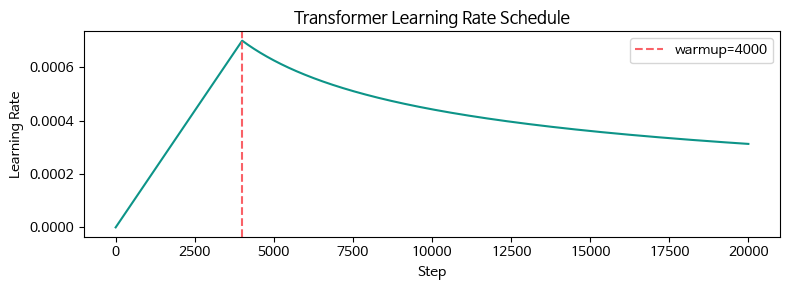

학습률 스케쥴러 클래스 정의


In [25]:
class NoamScheduler(torch.optim.lr_scheduler._LRScheduler):
    """
    Transformer 논문의 Noam Learning Rate Scheduler ('Attention Is All You Need')
    공식:
      lr = (d_model)^(-0.5) * min(step^(-0.5), step * (warmup_steps)^(-1.5))
    """
    def __init__(self, optimizer, d_model, warmup_steps=4000, last_epoch=-1):
        self.d_model = d_model  # 모델 차원
        self.warmup_steps = warmup_steps  # Warmup 단계 수

        super().__init__(optimizer, last_epoch)

    def get_lr(self):
        """
        현재 step의 학습률 계산
        """
        step = max(1, self.last_epoch)  # 현재 optimization step (최소 1)
        # PyTorch scheduler는 step() 호출 시점을 기준으로 동작하기 때문에 last_epoch 처리를 명확하게 해야한다.

        # d_model^(-0.5)
        #   모델 차원이 커질수록 Learning Rate를 작게 조정
        scale = 1 / math.sqrt(self.d_model)

        # step^(-0.5)
        # Warmup 이후 Learning Rate를 점진적으로 감소시키는 항
        decay = 1 / math.sqrt(step)

        # step * warmup_steps^(-1.5)
        # Warmup 구간에서 Learning Rate를 선형적으로 증가시키는 항
        warmup = step / (self.warmup_steps ** 1.5)

        # 두 값 중 작은 값을 선택
        # ① Warmup 단계 : warmup 항이 선택되어 LR 증가
        # ② Warmup 이후 : decay 항이 선택되어 LR 감소
        lr = scale * min(decay, warmup)

        # Optimizer의 모든 Parameter Group에 동일한 Learning Rate 적용
        return [lr for _ in self.base_lrs]


# LR 커브 시각화
steps = list(range(1, 20001))
d_model_check = 512
warmup_check  = 4000

lrs = [(d_model_check ** -0.5) * min(s**-0.5, s*(warmup_check**-1.5)) for s in steps]

plt.figure(figsize=(8, 3))
plt.plot(steps, lrs, color='#0D9488')
plt.axvline(x=warmup_check, color='#F96167', linestyle='--', label=f'warmup={warmup_check}')
plt.xlabel('Step'); plt.ylabel('Learning Rate')
plt.title('Transformer Learning Rate Schedule')
plt.legend(); plt.tight_layout(); plt.show()
print("학습률 스케쥴러 클래스 정의")

# 4. 학습 준비

## 트렌스포머 모델 하이퍼 파라미터 설정
---
| 파라미터 | 값 |
|---|---|
| NUM_LAYERS | 2 |
| D_MODEL | 512 |
| NUM_HEADS | 8 |
| D_FF | 2048 |
| DROPOUT | 0.3 |
| warmup_steps | 4000 |
| batch_size | 64 |
| epochs | 20 |


In [26]:
NUM_LAYERS    = 2
D_MODEL     = 512
NUM_HEADS     = 8
D_FF        = 2048
DROPOUT     = 0.3
WARMUP      = 4000
BATCH_SIZE  = 64
EPOCHS      = 20

SRC_VOCAB_SIZE = ko_tokenizer.get_piece_size()
TGT_VOCAB_SIZE = en_tokenizer.get_piece_size()


print("SRC vocab size:", SRC_VOCAB_SIZE)
print("TGT vocab size:", TGT_VOCAB_SIZE)

SRC vocab size: 20000
TGT vocab size: 20000


In [27]:
model = Transformer(
    src_vocab_size=SRC_VOCAB_SIZE,
    tgt_vocab_size=TGT_VOCAB_SIZE,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    d_ff=D_FF,
    num_layers=NUM_LAYERS,
    max_len=MAX_LEN,
    dropout=DROPOUT,
    shared=True
)


model = model.to(DEVICE)


print("Transformer 모델 생성 완료")

Transformer 모델 생성 완료


In [28]:
# 파라미터 수 확인
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'✅ 모델 파라미터 수: {total_params:,}')

✅ 모델 파라미터 수: 35,214,880


## Optimizer와 LRS 생성

---


#### Optimizer 생성
---


Transformer 논문에서는 Adam optimizer를 사용한다.

논문 설정:

+ β₁ = 0.9
+ β₂ = 0.98
+ ε = 1e-9

In [29]:
import torch.optim as optim


def build_optimizer(model, lr=1e-4):
    """
    Transformer 학습용 Adam Optimizer 생성

    Args:
        model:
            Transformer 모델

        lr:
            초기 learning rate

    Returns:
        Adam optimizer
    """

    optimizer = optim.Adam(
        model.parameters(),
        lr=lr,
        betas=(0.9, 0.98),
        eps=1e-9
    )

    return optimizer

In [30]:
# Optimizer 생성 (Scheduler가 optimizer를 필요로 하므로 Scheduler 앞에 생성)
optimizer = build_optimizer(model)

print("Optimizer 생성 완료")

Optimizer 생성 완료


#### LRS 생성

---
앞에서 만든 Scheduler는 Transformer 논문의 Noam Scheduler 이다.

$$lr=d_{model}^{−0.5}⋅min(step^{−0.5},step×warmup^{−1.5})$$

역할 :

  초기 :
  ```text
  warmup
  ↓
  learning rate 증가
  ```

  이후:
  ```text
  step 증가
  ↓
  learning rate 감소
  ```

In [31]:
def build_scheduler(
    optimizer,
    d_model,
    warmup_steps=4000
):

    scheduler = NoamScheduler(
        optimizer,
        d_model=d_model,
        warmup_steps=warmup_steps
    )

    return scheduler

In [32]:
scheduler = build_scheduler(
    optimizer,
    d_model=D_MODEL,
    warmup_steps=4000
)


print("Scheduler 생성 완료")

Scheduler 생성 완료


In [33]:
# Optimizer + Scheduler 연결 확인
print(
    optimizer.param_groups[0]['lr']
) # step=0, warmup 시작 전이라 매우 작은 값이 나옴

1.7469281074217108e-07


## Loss 함수 정의

In [34]:
# Loss 함수 정의

def loss_function(real, pred):
    """
    PAD token을 제외한 Cross Entropy Loss

    Args:
        real:
            [batch_size, seq_len]

        pred:
            [batch_size, seq_len, vocab_size]

    Returns:
        scalar loss
    """

    criterion = nn.CrossEntropyLoss(reduction='none')

    # PAD 토큰(0)이 아닌 위치를 True로 마킹
    mask = (real != 0)

    # CrossEntropyLoss 입력 형태 변경
    pred = pred.transpose(1, 2)
    # [B, seq_len, vocab_size]
    # ->
    # [B, vocab_size, seq_len]

    # token별 loss 계산
    loss = criterion(pred, real)
    # [B, seq_len]

    # PAD 위치 loss 제거
    mask = mask.float()
    loss *= mask

    # 실제 token 개수 기준 평균
    return loss.sum() / mask.sum()

print("Loss 함수 정의")

Loss 함수 정의


## Train Step 함수 정의

---


Transformer 기준 흐름:
```text
input batch
      |
      v
Encoder Forward
      |
      v
Decoder Forward
      |
      v
Prediction logits
      |
      v
Loss 계산
      |
      v
Backward()
      |
      v
Gradient update
```

즉, `train_step()`함수 안에서
+ Gradient 초기화
+ Forward pass
+ Loss 계산
+ Backpropagation
+ Optimizer step
+ Scheduler step
를 처리한다.


In [35]:
def train_step(src, tgt_input, tgt_label, model, optimizer, scheduler):
    """
    한 배치에 대한 훈련 스텝

    인자:
        src: 소스 시퀀스 [batch_size, src_len]
        tgt_input: 타겟 인풋 시퀀스 <eos> 제외 [batch_size, tgt_input_len] <eos> 제외
        tgt_label : 타겟 라벨 시퀀스 <bos> 제외 [batch_size, tgt_label_len]
        model: Transformer 모델
        optimizer: Adam Optimizer
        scheduler: Learning Rate Scheduler
    """

    # 데이터를 GPU로 이동
    src = src.to(DEVICE)
    tgt_input = tgt_input.to(DEVICE)
    tgt_label = tgt_label.to(DEVICE)

    # 마스크 생성
    src_mask, tgt_mask = build_masks(src, tgt_input)

    src_mask = src_mask.to(DEVICE)
    tgt_mask = tgt_mask.to(DEVICE)

    # 역전파 초기화
    optimizer.zero_grad()

    # 순전파
    predictions, enc_attns, dec_attns, dec_enc_attns = model(src, tgt_input, src_mask, tgt_mask)

    # Loss 계산 (prediction의 마지막 토큰 제외)
    loss = loss_function(tgt_label, predictions)

    # 역전파
    loss.backward()

    # Gradient Clipping (안정성을 위해)
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

    # 가중치 업데이트
    optimizer.step()

    # 학습률 업데이트 (배치마다)
    scheduler.step()

    return loss, enc_attns, dec_attns, dec_enc_attns

print("Train Step 함수 정의")

Train Step 함수 정의


# 5. 학습 함수

### Attention 시각화 함수

In [36]:
# Attention 시각화 함수

def visualize_attention(src_pieces, tgt_pieces, enc_attns, dec_attns, dec_enc_attns):
    """
    Attention 가중치를 시각화하는 함수

    인자:
        src_pieces: 소스 토큰 리스트
        tgt_pieces: 타겟 토큰 리스트
        enc_attns: 인코더 어텐션 가중치 (레이어별)
        dec_attns: 디코더 셀프 어텐션 가중치 (레이어별)
        dec_enc_attns: 디코더-인코더 크로스 어텐션 가중치 (레이어별)
    """
    import seaborn

    def draw(data, ax, x="auto", y="auto"):
        """히트맵 그리기"""
        seaborn.heatmap(data,
                        square=True,
                        vmin=0.0, vmax=1.0,
                        cbar=False, ax=ax,
                        xticklabels=x,
                        yticklabels=y)

    # 인코더 어텐션 시각화
    for layer in range(len(enc_attns)):
        fig, axs = plt.subplots(1, 4, figsize=(20, 5))
        print(f"Encoder Layer {layer + 1}")

        # 4개의 헤드 시각화
        for h in range(min(4, enc_attns[layer].shape[1])):
            # enc_attns[layer]: [batch, num_heads, seq_len, seq_len]
            attn_data = enc_attns[layer][0, h, :len(src_pieces), :len(src_pieces)].cpu().numpy()
            draw(attn_data, axs[h], src_pieces, src_pieces)

        plt.tight_layout()
        plt.show()

    # 디코더 셀프 어텐션 시각화
    for layer in range(len(dec_attns)):
        fig, axs = plt.subplots(1, 4, figsize=(20, 5))
        print(f"Decoder Self Attention Layer {layer + 1}")

        for h in range(min(4, dec_attns[layer].shape[1])):
            # dec_attns[layer]: [batch, num_heads, seq_len, seq_len]
            attn_data = dec_attns[layer][0, h, :len(tgt_pieces), :len(tgt_pieces)].cpu().numpy()
            draw(attn_data, axs[h], tgt_pieces, tgt_pieces)

        plt.tight_layout()
        plt.show()

    # 디코더-인코더 크로스 어텐션 시각화
    for layer in range(len(dec_enc_attns)):
        fig, axs = plt.subplots(1, 4, figsize=(20, 5))
        print(f"Decoder-Encoder Cross Attention Layer {layer + 1}")

        for h in range(min(4, dec_enc_attns[layer].shape[1])):
            # dec_enc_attns[layer]: [batch, num_heads, tgt_len, src_len]
            attn_data = dec_enc_attns[layer][0, h, :len(tgt_pieces), :len(src_pieces)].cpu().numpy()
            draw(attn_data, axs[h], src_pieces, tgt_pieces)

        plt.tight_layout()
        plt.show()

print("✅ Attention 시각화 함수 정의")

✅ Attention 시각화 함수 정의


### evaluate 함수 - 번역 후 어텐션 가중치 반환

In [37]:
def evaluate(sentence, model, src_tokenizer, tgt_tokenizer, max_len=50):
    """
    단일 문장 번역 및 Attention 반환

    Returns:
        src_pieces
        result
        enc_attns
        dec_attns
        dec_enc_attns
    """

    model.eval()

    with torch.no_grad():
        # 입력 전처리 및 토큰화
        sentence = preprocess_sentence(sentence)
        src_pieces = src_tokenizer.encode_as_pieces(sentence)
        src_ids = src_tokenizer.encode_as_ids(sentence)

        # padding
        src_ids = src_ids[:max_len]
        src_ids += [src_tokenizer.pad_id()] * (max_len - len(src_ids))

        src = torch.tensor([src_ids], dtype=torch.long).to(DEVICE)

        # 인코더 마스크
        src_mask = generate_padding_mask(
            src,
            src_tokenizer.pad_id()
        ).to(DEVICE)

        # Encoder Forward
        enc_emb = model.source_emb(src)
        enc_emb = enc_emb * math.sqrt(model.d_model)

        enc_emb = model.pos_encoding(enc_emb)

        enc_out, enc_attns = model.encoder(
            enc_emb,
            src_mask
        )

        # Decoder Autoregressive 생성
        tgt_ids = [tgt_tokenizer.bos_id()]

        dec_attns_final = None
        dec_enc_attns_final = None

        # 자기회귀 생성
        for i in range(max_len):
            tgt = torch.tensor(
                [tgt_ids],
                dtype=torch.long
            ).to(DEVICE)

            # Decoder mask
            tgt_len = tgt.size(1)

            causal_mask = generate_causal_mask(
                tgt_len,
                DEVICE
            )


            # Decoder embedding
            dec_emb = model.target_emb(tgt)
            dec_emb = dec_emb * math.sqrt(model.d_model)
            dec_emb = model.pos_encoding(dec_emb)


            # Decoder forward
            dec_out, dec_attns, dec_enc_attns = model.decoder(
                dec_emb,
                enc_out,
                causal_mask,
                src_mask
            )


            # 마지막 토큰 prediction
            logits = model.generator(dec_out[:, -1])
            next_token = torch.argmax(logits, dim=-1).item()


            # attention 저장
            dec_attns_final = dec_attns
            dec_enc_attns_final = dec_enc_attns


            # EOS 종료
            if next_token == tgt_tokenizer.eos_id():
                break


            tgt_ids.append(next_token)

        # Decode
        result_ids = tgt_ids[1:]

        result = tgt_tokenizer.decode_ids(
            result_ids
        )


        return (
            src_pieces,
            result,
            enc_attns,
            dec_attns_final,
            dec_enc_attns_final
        )


print("evaluate 함수 완료")

evaluate 함수 완료


## translate 함수

In [38]:
# 번역 생성 및 Attention 시각화 결합

def translate(sentence, model, src_tokenizer, tgt_tokenizer, plot_attention=False):
    """
    문장을 번역하고 선택적으로 어텐션을 시각화

    인자:
        sentence: 번역할 문장
        model: Transformer 모델
        src_tokenizer: 소스 토크나이저
        tgt_tokenizer: 타겟 토크나이저
        plot_attention: 어텐션 시각화 여부
    """
    src_pieces, result, enc_attns, dec_attns, dec_enc_attns = \
        evaluate(sentence, model, src_tokenizer, tgt_tokenizer)

    print(f'입력: {sentence}')
    print(f'번역: {result}\n')

    if plot_attention:
        tgt_pieces = tgt_tokenizer.encode_as_pieces(result)
        visualize_attention(src_pieces, tgt_pieces, enc_attns, dec_attns, dec_enc_attns)

    return result

print("✅ translate 함수 정의")

✅ translate 함수 정의


입력: 오바마는 대통령이다.
번역: 

Encoder Layer 1


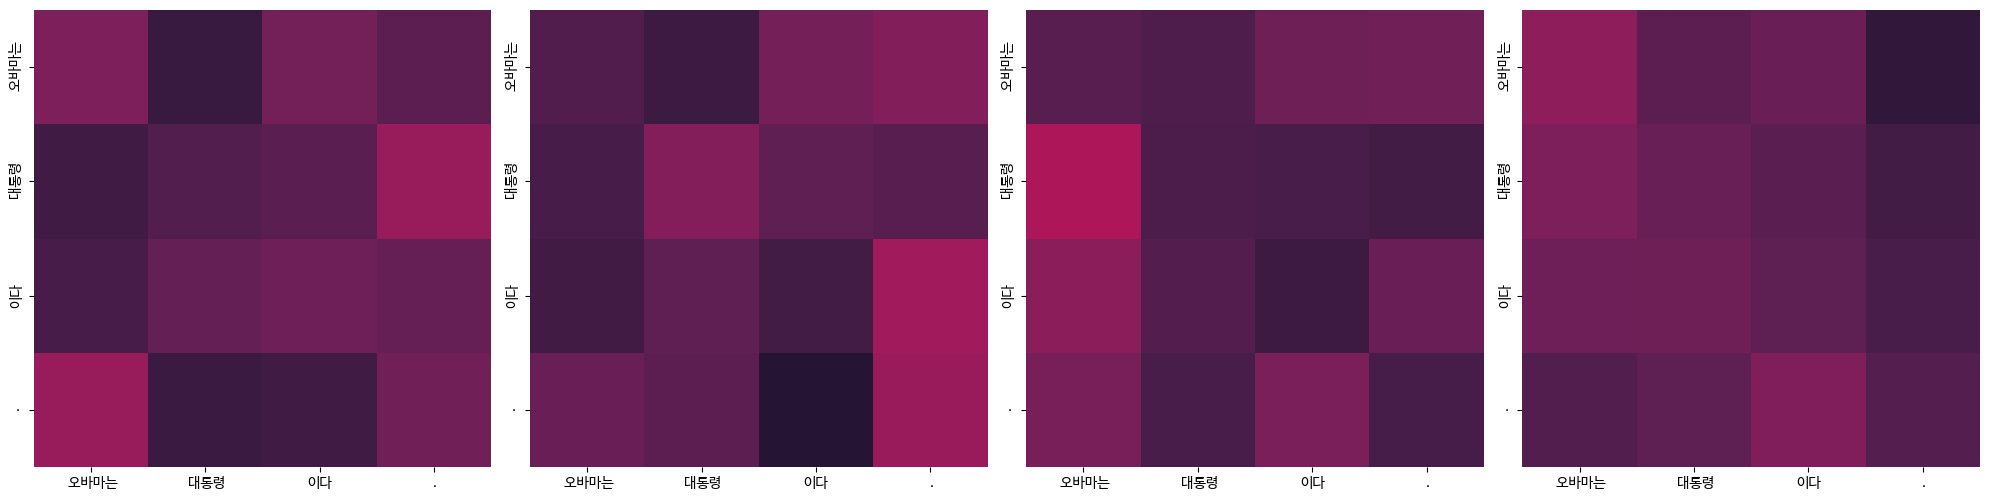

Encoder Layer 2


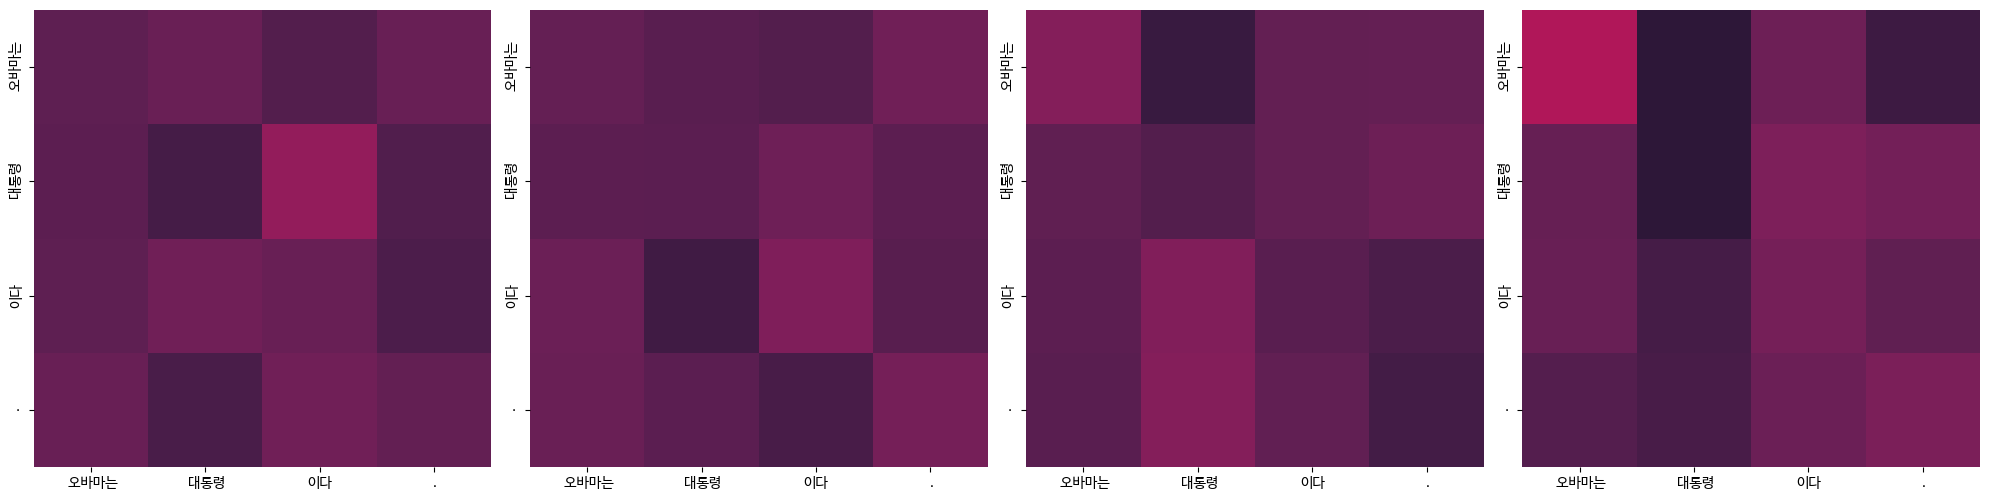

Decoder Self Attention Layer 1


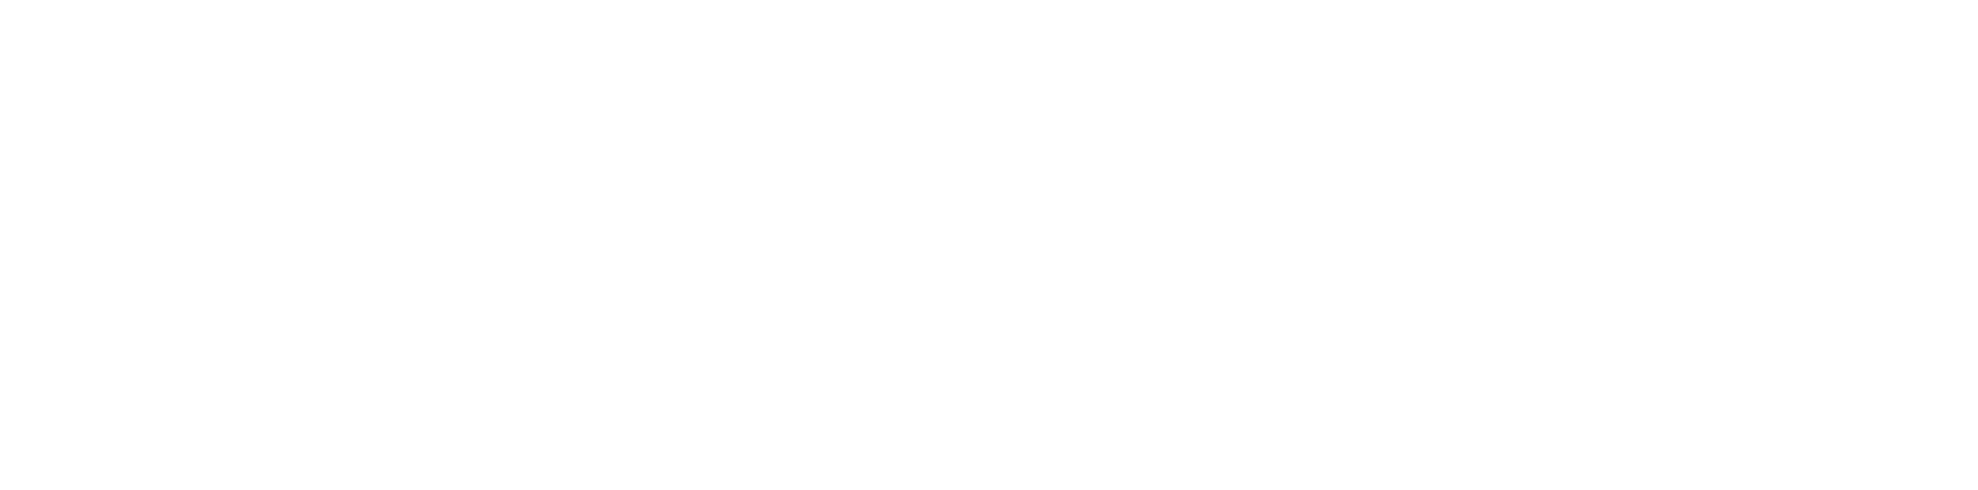

Decoder Self Attention Layer 2


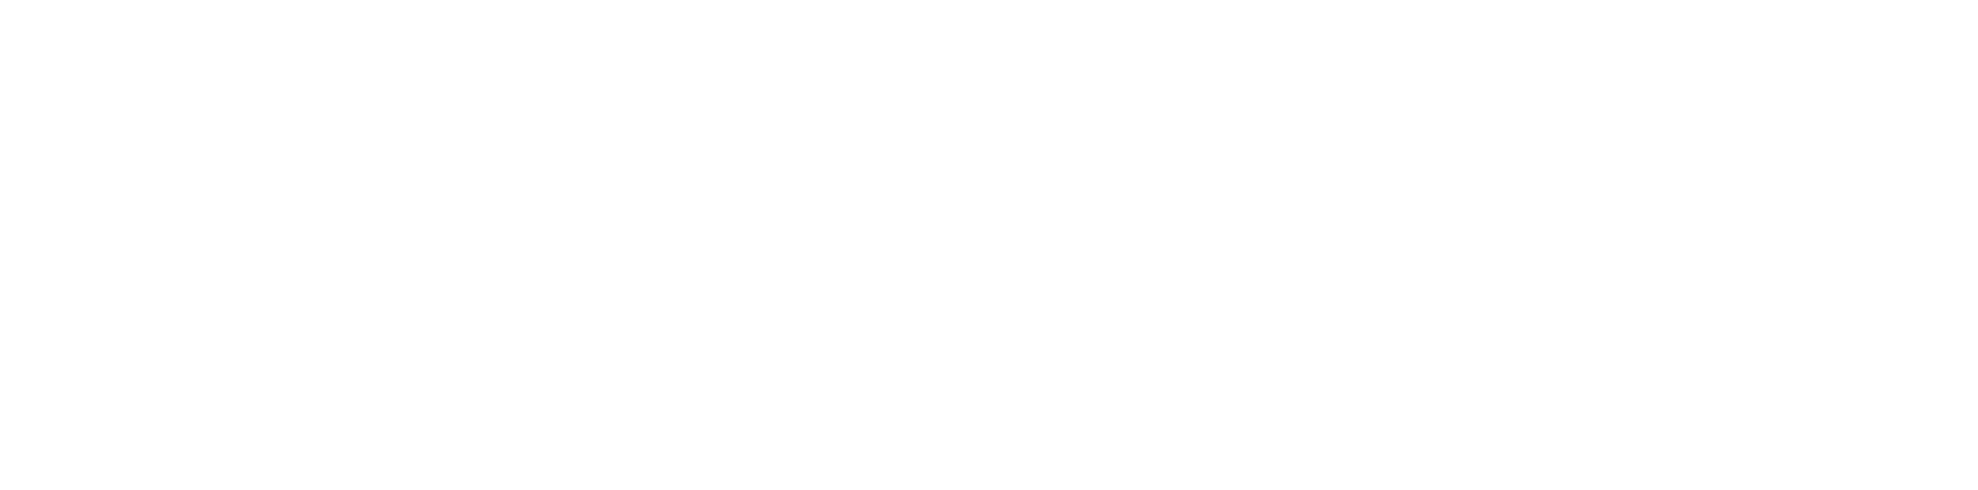

Decoder-Encoder Cross Attention Layer 1


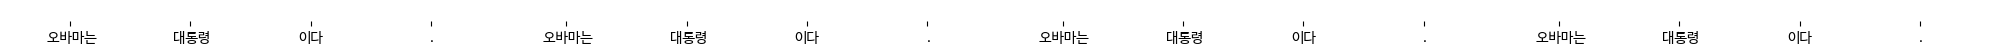

Decoder-Encoder Cross Attention Layer 2


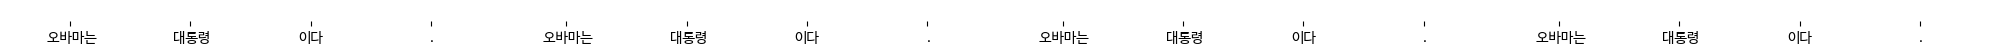

''

In [39]:
# translate 함수 동작 확인
translate(
    "오바마는 대통령이다.",
    model,
    ko_tokenizer,
    en_tokenizer,
    plot_attention=True
)

## Train / Validation 데이터 분리

In [40]:
from torch.utils.data import TensorDataset, DataLoader, random_split


# Dataset 생성
dataset = TensorDataset(
    enc_train,
    dec_train
)


# Train / Validation split
VAL_RATIO = 0.1

val_size = int(len(dataset) * VAL_RATIO)
train_size = len(dataset) - val_size


train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size]
)


print(f"Train size : {len(train_dataset)}")
print(f"Valid size : {len(val_dataset)}")

Train size : 66839
Valid size : 7426


## DataLoader 생성

In [41]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=False
)


val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False
)

## Validation 함수

In [42]:
def validate_step(
    src,
    tgt,
    model,
    loss_function
):

    model.eval()

    with torch.no_grad():

        # decoder input / label 분리
        tgt_input = tgt[:, :-1]
        tgt_label = tgt[:, 1:]


        src = src.to(DEVICE)
        tgt_input = tgt_input.to(DEVICE)
        tgt_label = tgt_label.to(DEVICE)


        # mask 생성
        src_mask, tgt_mask = build_masks(
            src,
            tgt_input
        )


        src_mask = src_mask.to(DEVICE)
        tgt_mask = tgt_mask.to(DEVICE)


        # forward
        prediction, _, _, _ = model(
            src,
            tgt_input,
            src_mask,
            tgt_mask
        )


        loss = loss_function(
            tgt_label,
            prediction
        )


    return loss.item()

## Train Loop

In [43]:
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import os


CHECKPOINT_DIR = "./checkpoints"

os.makedirs(
    CHECKPOINT_DIR,
    exist_ok=True
)

BEST_CHECKPOINT_PATH = (
    f"{CHECKPOINT_DIR}/best_transformer_checkpoint.pt"
)



history = {"train_loss": [], "val_loss": []}


examples = [
    "오바마는 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요 없다.",
    "일곱 명의 사망자가 발생했다."
]


best_val_loss = float("inf")

BEST_MODEL_PATH = os.path.join(
    CHECKPOINT_DIR,
    "best_transformer.pt"
)


print("🚀 Training Start")


for epoch in range(EPOCHS):

    # ==========================
    # Train
    # ==========================

    model.train()

    total_train_loss = 0


    progress = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")


    for src, tgt in progress:


        # Decoder input / label 분리
        tgt_input = tgt[:, :-1]
        tgt_label = tgt[:, 1:]


        loss, _, _, _ = train_step(
            src,
            tgt_input,
            tgt_label,
            model,
            optimizer,
            scheduler
        )


        total_train_loss += loss.item()


        progress.set_postfix(loss=f"{loss.item():.4f}")


    avg_train_loss = (total_train_loss / len(train_loader))


    # ==========================
    # Validation
    # ==========================

    model.eval()

    total_val_loss = 0


    for src, tgt in val_loader:

        loss = validate_step(
            src,
            tgt,
            model,
            loss_function
        )

        total_val_loss += loss


    avg_val_loss = (total_val_loss / len(val_loader))


    # History 저장

    history["train_loss"].append(avg_train_loss)

    history["val_loss"].append(avg_val_loss)


    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    print(f"Train Loss : {avg_train_loss:.4f}")

    print(f"Valid Loss : {avg_val_loss:.4f}")


    # ==========================
    # Best Model 저장
    # ==========================

    if avg_val_loss < best_val_loss:

        best_val_loss = avg_val_loss

        checkpoint = {
          "epoch": epoch + 1,
          "model": model.state_dict(),
          "optimizer": optimizer.state_dict(),
          "scheduler": scheduler.state_dict(),
          "best_loss": best_val_loss
        }

        torch.save(checkpoint, BEST_MODEL_PATH)

        print("✅ Best model saved")


    # ==========================
    # 5 Epoch마다 체크포인트 + 번역 확인
    # ==========================

    if (epoch + 1) % 5 == 0:


        # ----------------------
        # Checkpoint 저장
        # ----------------------

        checkpoint_path = (f"{CHECKPOINT_DIR}/epoch_{epoch+1:02d}.pt")
        checkpoint = {
          "epoch": epoch + 1,
          "model": model.state_dict(),
          "optimizer": optimizer.state_dict(),
          "scheduler": scheduler.state_dict(),
          "best_loss": best_val_loss
        }
        torch.save(checkpoint, checkpoint_path)


        print(f"\n💾 Checkpoint saved : {checkpoint_path}")


        # ----------------------
        # Translation Test
        # ----------------------

        print("\nTranslation Test")

        model.eval()

        for example in examples:

            translate(
                example,
                model,
                ko_tokenizer,
                en_tokenizer,
                plot_attention=False
            )


        print("-"*50)



print("\n🎉 Training Finished")

🚀 Training Start


Epoch 1/20:   0%|          | 0/1045 [00:00<?, ?it/s]


Epoch 1/20
Train Loss : 7.2045
Valid Loss : 5.9092
✅ Best model saved


Epoch 2/20:   0%|          | 0/1045 [00:00<?, ?it/s]


Epoch 2/20
Train Loss : 5.6035
Valid Loss : 5.1997
✅ Best model saved


...

Epoch 19/20:   0%|          | 0/1045 [00:00<?, ?it/s]


Epoch 19/20
Train Loss : 2.9480
Valid Loss : 3.9980


Epoch 20/20:   0%|          | 0/1045 [00:00<?, ?it/s]


Epoch 20/20
Train Loss : 2.9055
Valid Loss : 4.0074

💾 Checkpoint saved : ./checkpoints/epoch_20.pt

Translation Test
입력: 오바마는 대통령이다.
번역: obama is a president .

입력: 시민들은 도시 속에 산다.
번역: people are in the city .

입력: 커피는 필요 없다.
번역: coffee is not necessary .

입력: 일곱 명의 사망자가 발생했다.
번역: seven deaths were reported in the area .

--------------------------------------------------

🎉 Training Finished


RuntimeError: Error(s) in loading state_dict for Transformer:
	Missing key(s) in state_dict: "source_emb.weight", "target_emb.weight", "pos_encoding.pe", "encoder.enc_layers.0.enc_self_attn.W_q.weight", "encoder.enc_layers.0.enc_self_attn.W_q.bias", "encoder.enc_layers.0.enc_self_attn.W_k.weight", "encoder.enc_layers.0.enc_self_attn.W_k.bias", "encoder.enc_layers.0.enc_self_attn.W_v.weight", "encoder.enc_layers.0.enc_self_attn.W_v.bias", "encoder.enc_layers.0.enc_self_attn.fc.weight", "encoder.enc_layers.0.enc_self_attn.fc.bias", "encoder.enc_layers.0.ffn.fc1.weight", "encoder.enc_layers.0.ffn.fc1.bias", "encoder.enc_layers.0.ffn.fc2.weight", "encoder.enc_layers.0.ffn.fc2.bias", "encoder.enc_layers.0.norm1.weight", "encoder.enc_layers.0.norm1.bias", "encoder.enc_layers.0.norm2.weight", "encoder.enc_layers.0.norm2.bias", "encoder.enc_layers.1.enc_self_attn.W_q.weight", "encoder.enc_layers.1.enc_self_attn.W_q.bias", "encoder.enc_layers.1.enc_self_attn.W_k.weight", "encoder.enc_layers.1.e

In [48]:
checkpoint = torch.load("./checkpoints/epoch_20.pt", weights_only=True)
model.load_state_dict(checkpoint["model"])
print(f"epoch {checkpoint['epoch']}, val_loss {checkpoint['best_loss']:.4f}")

epoch 20, val_loss 3.9791


### 번역 품질 추이 (5 epoch 간격)

| Epoch | "오바마는 대통령이다." |
|---|---|
| 5 | obama is the president . |
| 10 | obama is a president . |
| 15 | obama is a presidential candidate . |
| 20 | obama is a president . |

| Epoch | "시민들은 도시 속에 산다." |
|---|---|
| 5 | the city s city is the city of city . |
| 10 | **people are in the city .** |
| 15 | **people are in the city .** |
| 20 | **people are in the city .** |

| Epoch | "커피는 필요 없다." |
|---|---|
| 5 | it s not a good thing . |
| 10 | coffee is no need for coffee . |
| 15 | **coffee is not necessary .** |
| 20 | **coffee is not necessary .** |

| Epoch | "일곱 명의 사망자가 발생했다." |
|---|---|
| 5 | the death toll was killed in the city of baghdad . |
| 10 | the death toll was blamed for the deaths . |
| 15 | **seven deaths were reported in the city .** |
| 20 | **seven deaths were reported in the area .** |

Epoch 15~20에서 원문의 "일곱 명"이 "seven"으로 정확히 반영되는 등, 의미 반영 수준이 뚜렷하게 개선되었다.

# 6. 추론(Inference)

## Loss Curve 확인

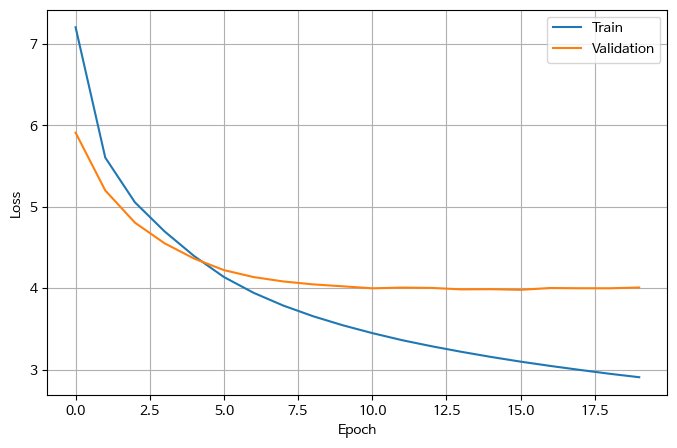

In [49]:
plt.figure(figsize=(8,5))

plt.plot(
    history["train_loss"],
    label="Train"
)

plt.plot(
    history["val_loss"],
    label="Validation"
)


plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.grid()

plt.show()

### Loss Curve 분석

| 구간 | Train Loss | Valid Loss | 관찰 |
|---|---|---|---|
| Epoch 1 | 7.20 | 5.91 | 정상 범위(`ln(20000)≈9.9` 근처)에서 시작 — 임베딩 초기화 수정 효과 재확인 |
| Epoch 5 | 4.39 | 4.36 | Train/Valid 거의 밀착, 정상적인 학습 곡선 |
| Epoch 10 | 3.54 | 4.02 | Valid 개선폭이 눈에 띄게 둔화 시작 |
| Epoch 11~16 | 3.45→3.10 | 3.998→**3.979(최저)** | Valid loss가 사실상 평평해짐, epoch 16이 최저점 |
| Epoch 17~20 | 3.04→2.91 | 4.00~4.01 | Train은 계속 감소하는데 Valid는 소폭 반등 → **과적합 시작** |

**결론**: Epoch 11 이후로는 Train/Valid 곡선이 벌어지는 전형적인 과적합 패턴으로 보인다. Best model은 <b>Epoch 16 (Valid Loss 3.9791)</b>이 으로 확인된다.

## Attention 확인

입력: 오바마는 대통령이다.
번역: obama is the president elect .

Encoder Layer 1


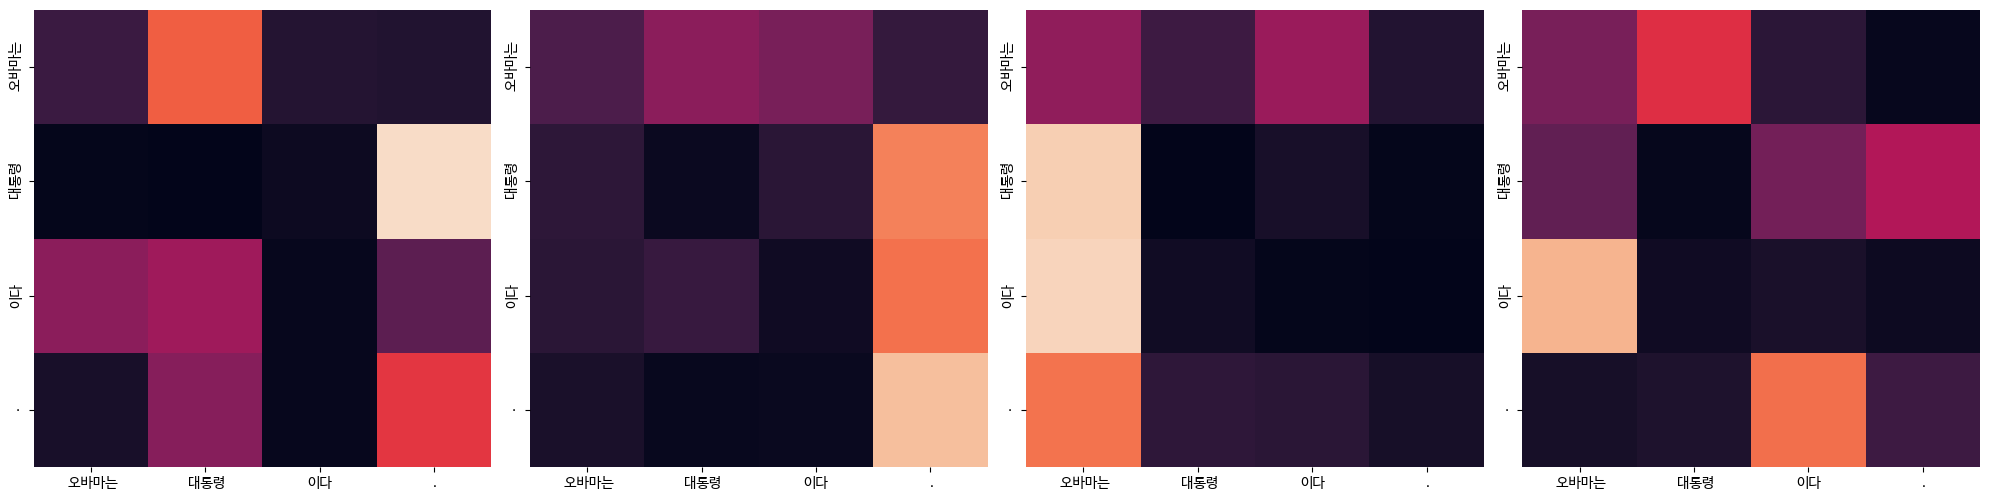

Encoder Layer 2


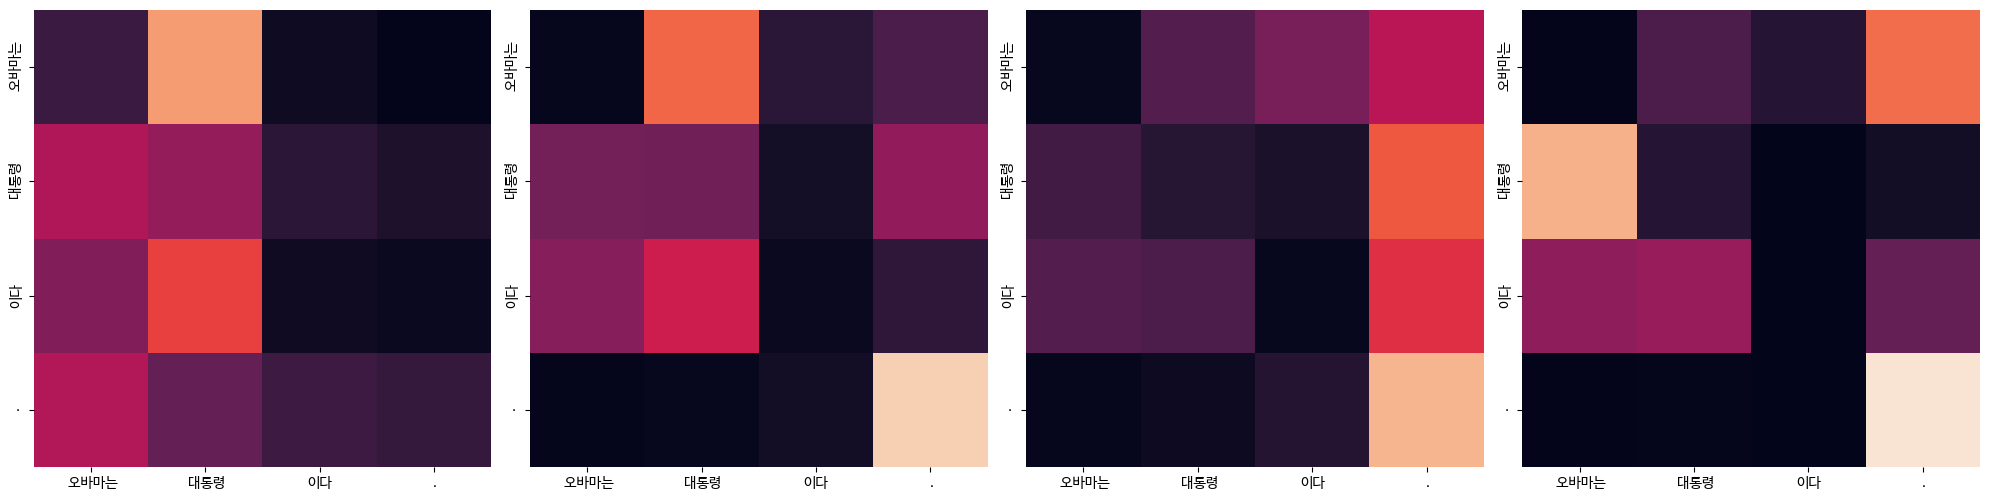

Decoder Self Attention Layer 1


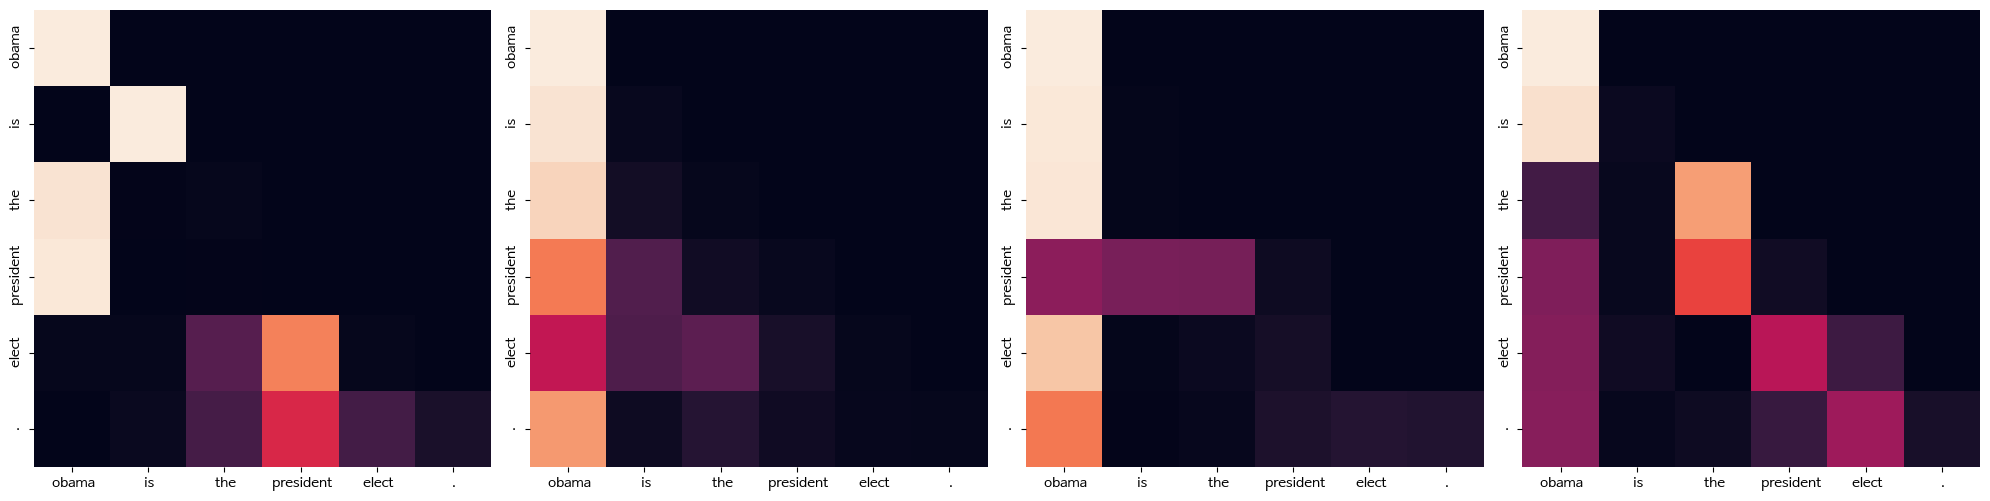

Decoder Self Attention Layer 2


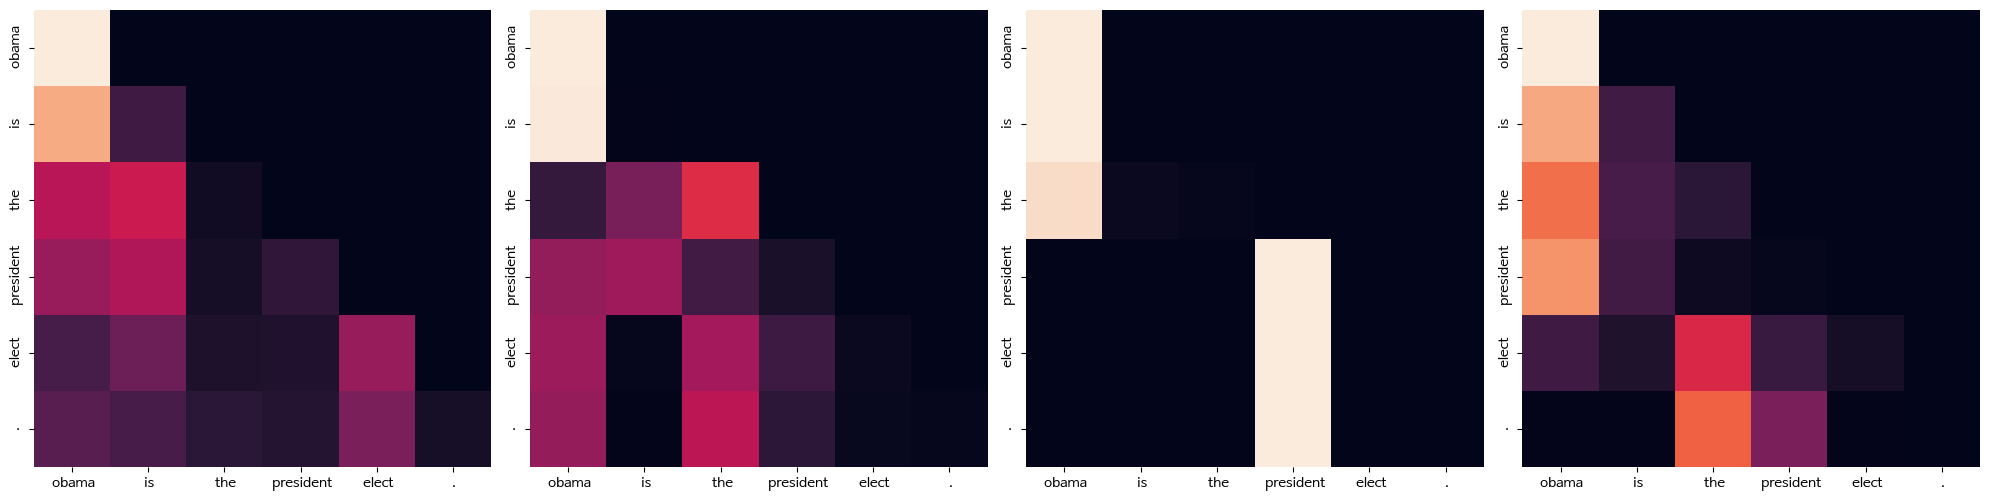

Decoder-Encoder Cross Attention Layer 1


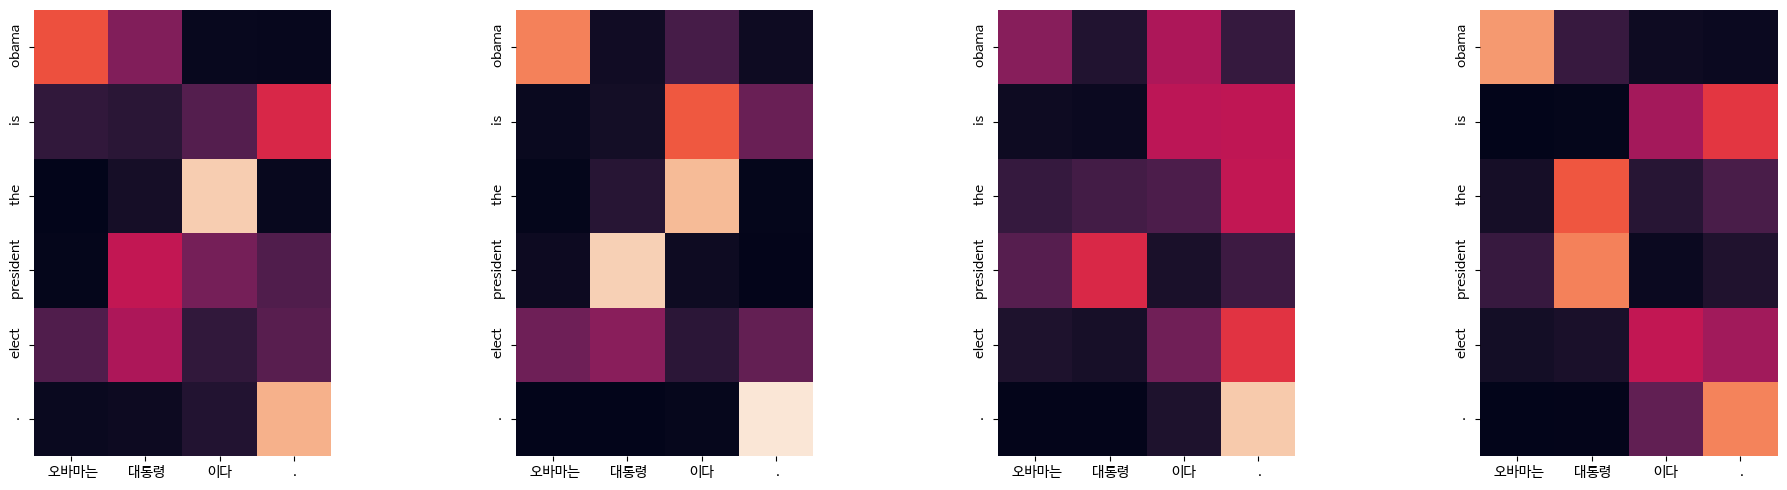

Decoder-Encoder Cross Attention Layer 2


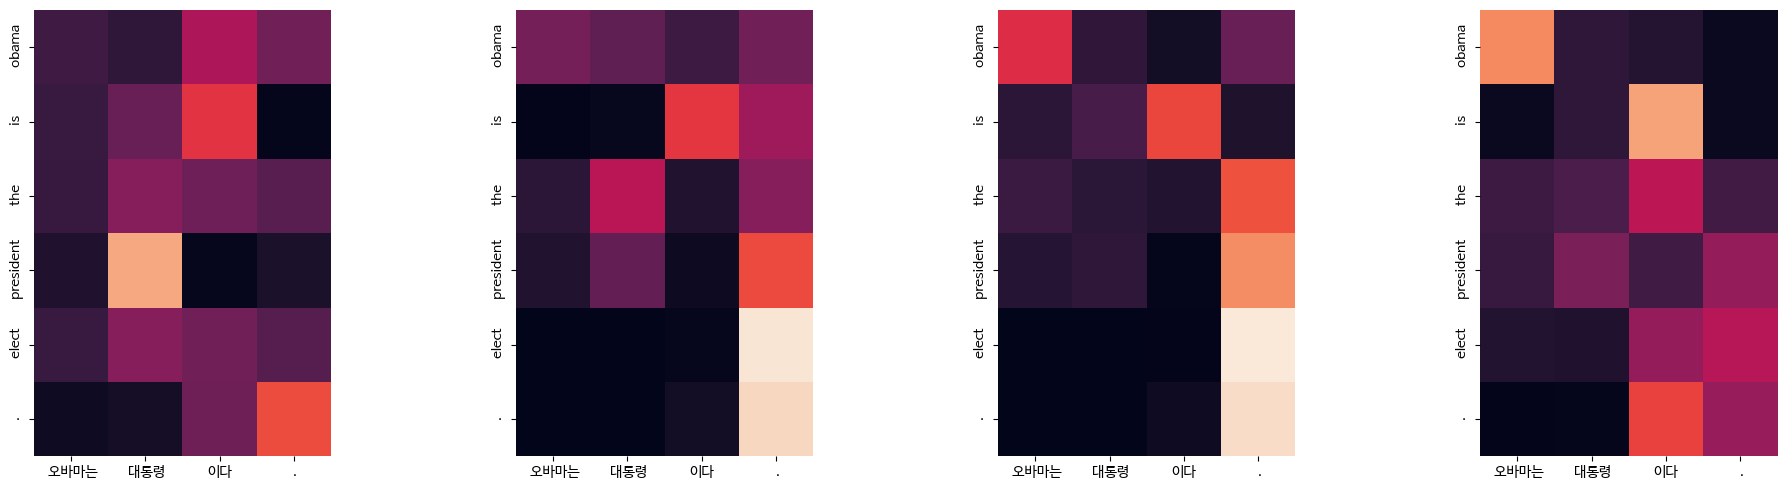

'obama is the president elect .'

In [47]:
translate(
    "오바마는 대통령이다.",
    model,
    ko_tokenizer,
    en_tokenizer,
    plot_attention=True
)

입력: 시민들은 도시 속에 산다.
번역: people are in the city .

Encoder Layer 1


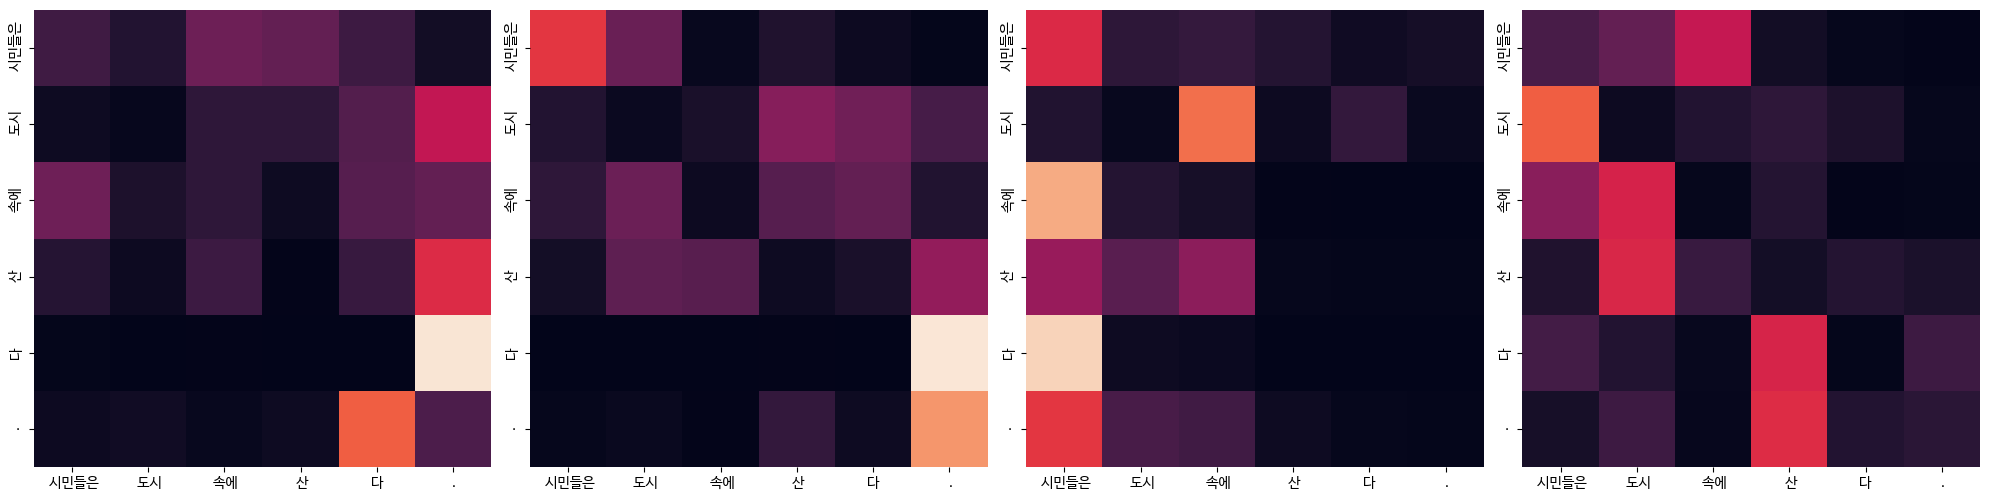

Encoder Layer 2


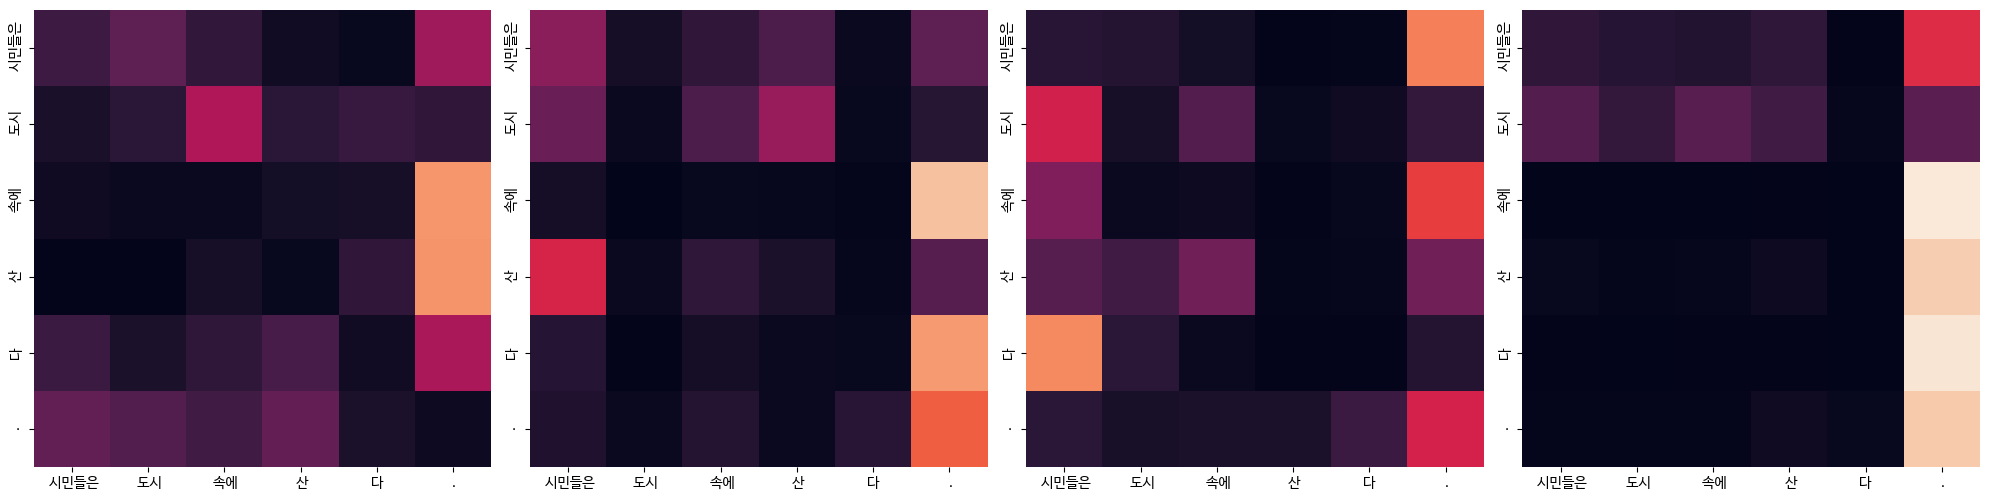

Decoder Self Attention Layer 1


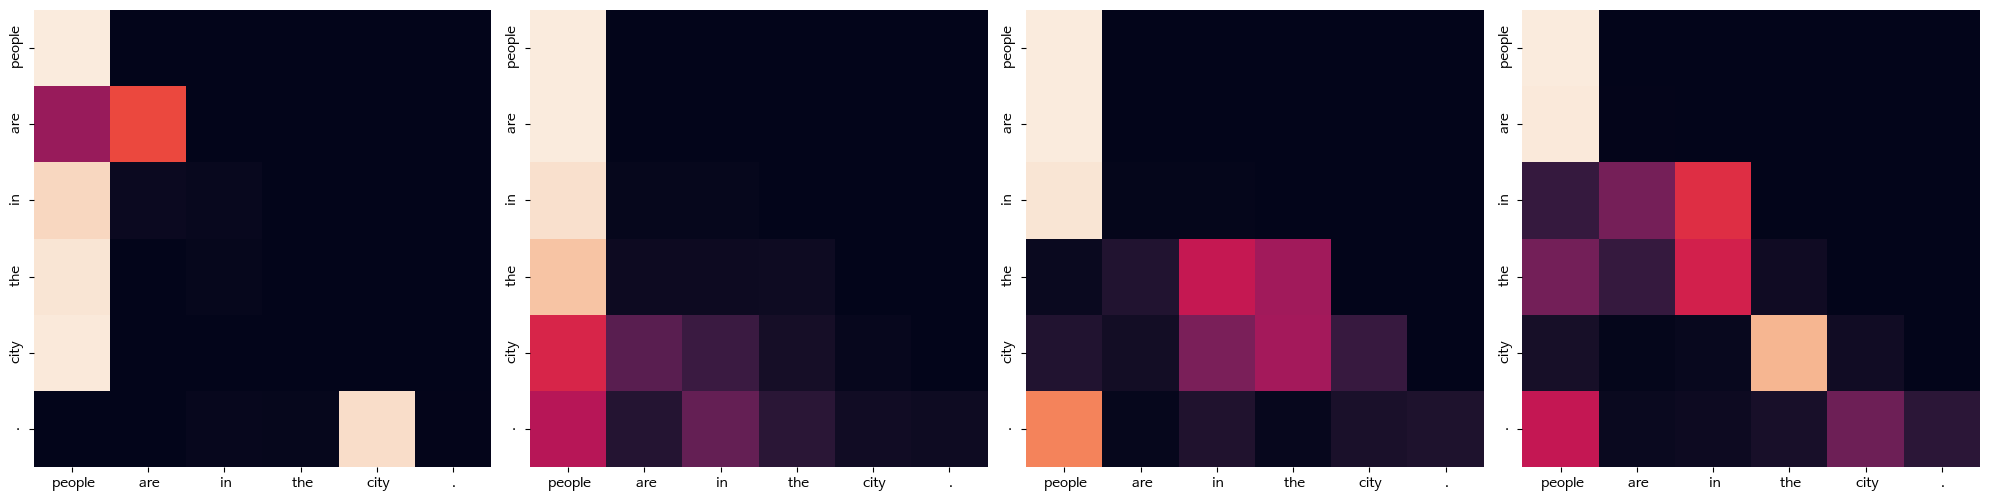

Decoder Self Attention Layer 2


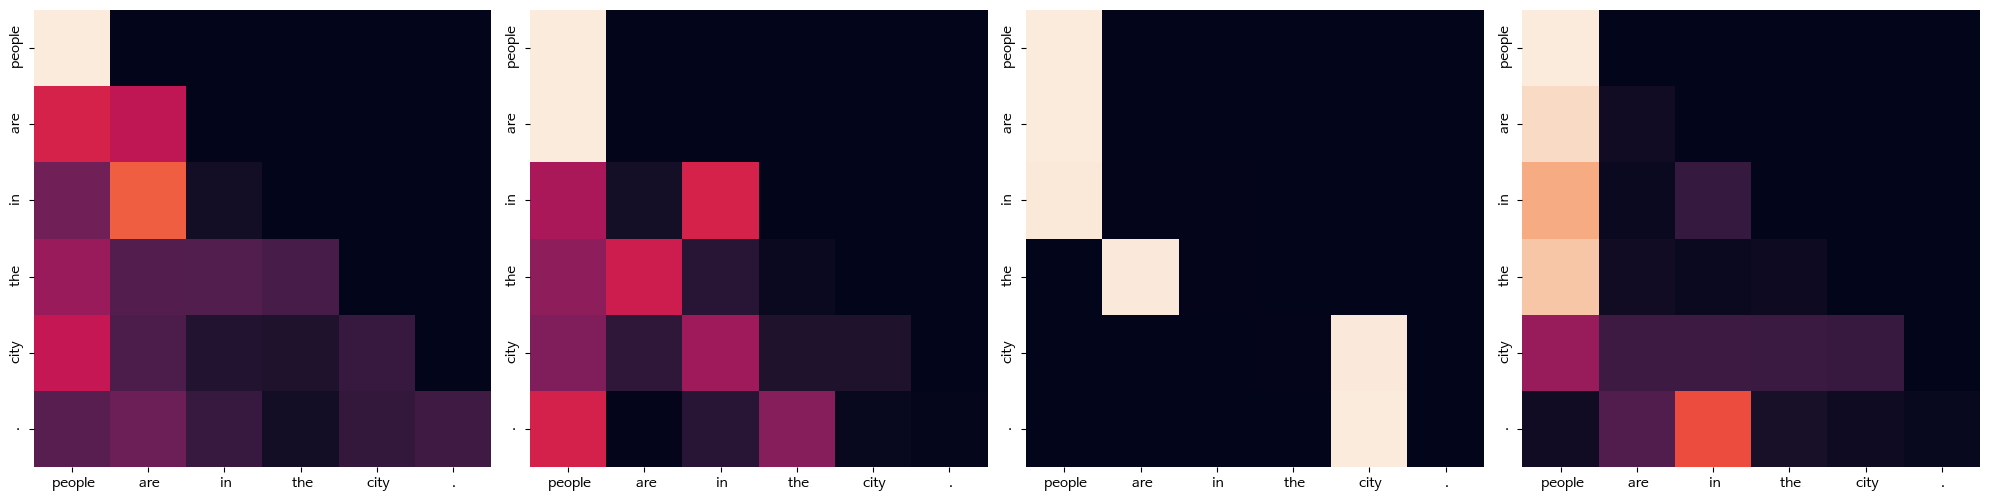

Decoder-Encoder Cross Attention Layer 1


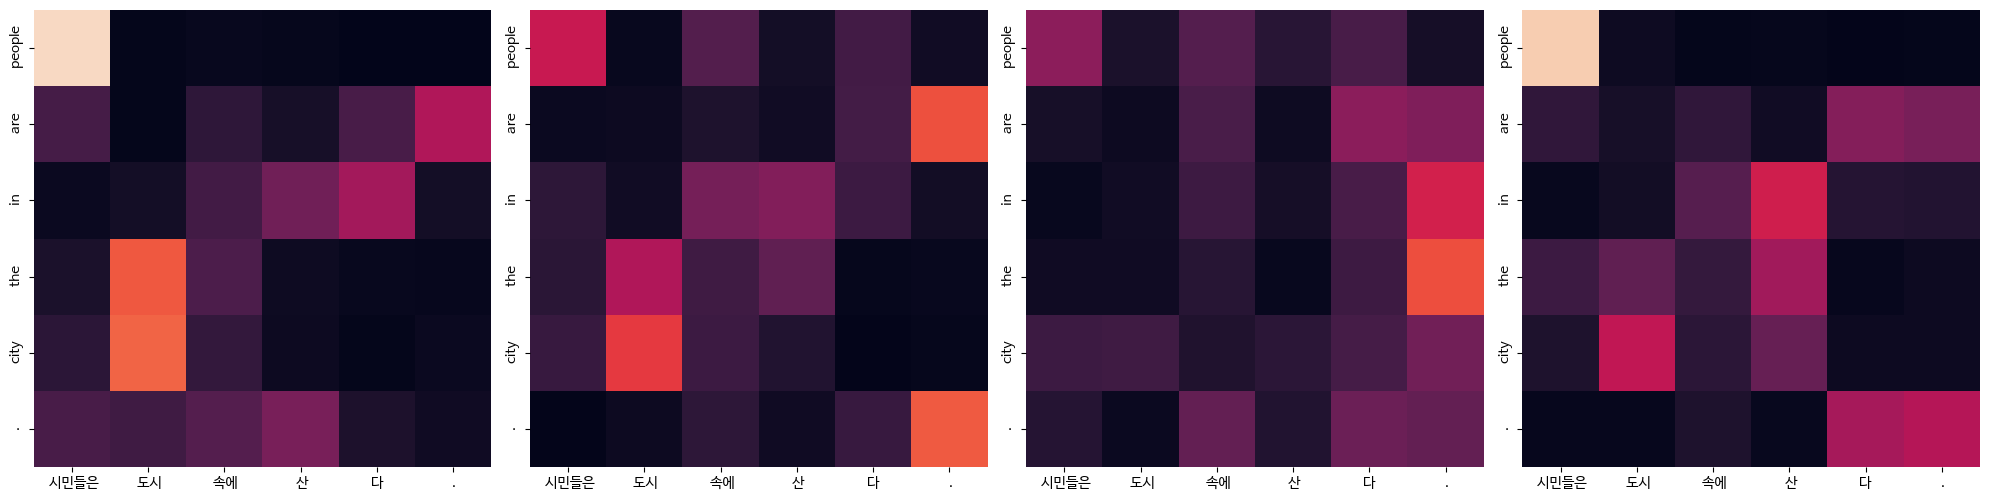

Decoder-Encoder Cross Attention Layer 2


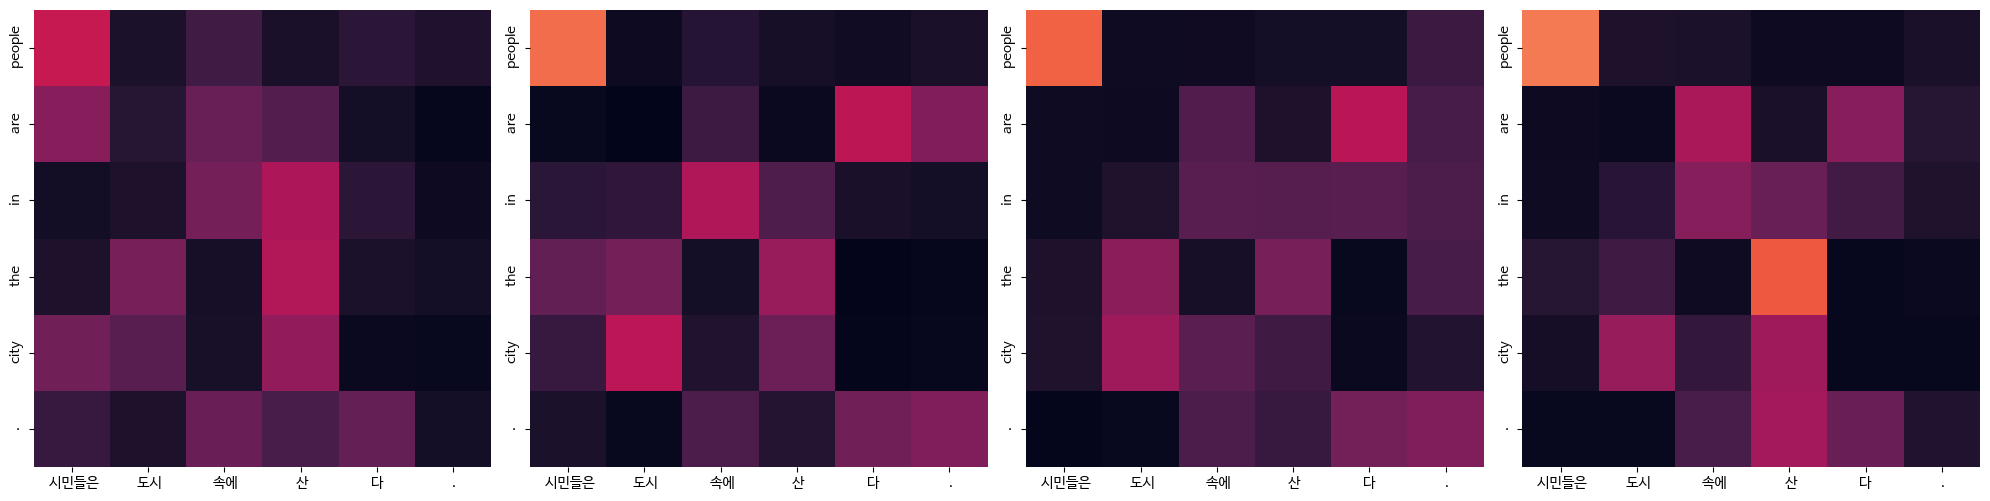

'people are in the city .'

In [51]:
translate(
    "시민들은 도시 속에 산다.",
    model,
    ko_tokenizer,
    en_tokenizer,
    plot_attention=True
)

### Attention 시각화 분석

(1) "오바마는 대통령이다."

- **Encoder Self-Attention**: 헤드별로 서로 다른 패턴을 보이며, 특정 토큰("대통령", "."）에 쏠리는 헤드와 대각선 위주로 보는 헤드가 공존 — 정상적인 학습된 어텐션의 특징이 보인다.
- **Decoder Self-Attention**: 상삼각 부분이 완전히 비어있고(0에 가까움) 하삼각만 값이 채워짐 — **Causal mask가 정확히 동작**하고 있다는 직접적인 시각적 증거다. 이 부분은 검증 표준에서 요구하는 "구조 검증"을 시각적으로 통과한 것으로 볼 수 있다.
- **Cross-Attention**: "obama"↔"오바마는", "president"↔"대통령" 근방에 밝은 값이 걸리는 등 정렬이 대체로 합리적이다.

(2) "시민들은 도시 속에 산다."

- **Decoder Self-Attention** — Causal Mask 정상 동작 (재확인) :<br>
  Layer 1·2 모두 상삼각 부분이 완전히 비어 있다. 이전 예시("오바마는...")에 이어 이번 문장에서도 동일하게 확인되므로, causal masking이 우연이 아니라 구조적으로 제대로 박혀 있다는 근거가 하나 더 늘어났다.
- **Cross-Attention** : 의미 정렬이 실제로 맞다
  Layer 1 첫 번째 헤드에서:<br>

  people 행 → `시민들은` 열에 가장 밝은 값  
  the/city 행 → `도시` 열에 가장 밝은 값 <br><br>
  번역어와 원문 단어가 정확히 의미적으로 대응하는 위치에서 어텐션이 형성되어 있다. 이건 모델이 단순 암기가 아니라 실제 정렬(alignment)을 학습했다는 직접적인 증거이고, 지금까지의 리뷰 중 가장 강력한 정성적 검증 신호이다.
- **Encoder Layer 2** — "Attention Sink" 패턴 :  
  Layer 2의 4개 헤드 중 3개가 문장 끝의 `.` 토큰에 강하게 쏠려 있다. 이는 버그가 아니라 Transformer에서 흔히 보고되는 현상으로("attention sink"), 정보량이 적은 고정 토큰(문장 끝 punctuation, 혹은 BOS)에 잉여 어텐션을 몰아주는 경향이다. Layer 1에서는 각 헤드가 훨씬 다양한 패턴을 보이므로, 상위 레이어로 갈수록 이런 sink 현상이 나타나는 전형적인 양상과 일치한다. 성능 문제라기보다는 정상적인 학습된 표현으로 볼 수 있을 것 같다.

# NOTE

---

## 잘된 점


+ "Epoch 1 loss가 이론값보다 10배 이상 높다"는 단서 하나로 임베딩 초기화라는 근본 원인을 찾아냈고, 실제 재학습에서 그 가설이 정확히 들어맞았다. (126.78 → 7.20). 증상(반복 출력)만 보고 디코딩 로직을 의심하기 쉬웠는데, 학습 단계의 수치를 먼저 점검한 접근이 맞아떨어졌다.
+ 학습/추론 파이프라인 정합성(토크나이저 메서드, BOS/EOS 처리, 마스킹)은 처음부터 끝까지 흔들림 없이 유지되었다. Decoder self-attention의 상삼각이 완전히 비어있는 시각화 결과가 이를 방증한다.
+ 데이터 정제 → 텐서 변환 → 학습 → 체크포인트 → 추론까지 전체 흐름이 한 번 끊김(체크포인트 dict 구조 변경 후 로드 코드 미반영, 실수로 파일 삭제) 있었음에도 원인 파악과 재학습으로 무리 없이 복구되었다.


## 아쉬운 점 / 배울 점


+ 체크포인트 저장 포맷(state_dict → {"model": state_dict, ...} dict)을 바꿀 때 로드 코드를 함께 바꾸지 않아 런타임 에러가 났고, 최종본에서는 그 셀을 고치는 대신 삭제하는 방식으로 우회했다. 그 결과 지금 추론에 쓰인 가중치가 "진짜 best(epoch 16)"가 아니라 "마지막(epoch 20, 약간 과적합)"이라는 점을 스스로 인지하지 못한 채 넘어갈 뻔했다. 저장 포맷을 바꾸는 리팩터링을 할 때는 그 값을 소비하는 모든 지점(save↔load 쌍)을 항상 같이 검토해야 한다는 교훈을 얻었다.
+ Best model 파일이 로컬/Colab 세션에만 있다가 실수로 삭제되는 사고가 있었다. 학습 결과물처럼 재생성 비용이 큰 산출물은 학습 스크립트 자체에 "Drive/외부 저장소로 자동 백업" 단계를 넣어두는 습관을 들여야겠다.
+ 다음 프로젝트에서는 "성능에 영향 없는 정리 항목"도 초반에 같이 반영해두어 이후 디버깅 비용을 줄일 수 있도록 해야겠다.


## 다음 액션 (우선순위 순)


+ Best model(epoch 16) 기준으로 Loss Curve 이후 셀 재실행 — 지금 결과와 큰 차이가 있는지 확인
+ Label smoothing 적용 (ignore_index=0, label_smoothing=0.1) 후 재학습 — 반복 억제 및 calibration 개선 기대
+ Attention 시각화 라벨을 evaluate()에서 생성 중 사용한 tgt_ids 기반으로 교체
+ clean_corpus 전역 변수 제거 — 재실행 안전성 확보